<a href="https://colab.research.google.com/github/salmaanika09-sketch/thesis-ultimate_load_prediction_ML_pipeline/blob/main/T_joint_Final_Latest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
✓ Setup complete
✓ Imports and style ready
Specimens     : 617 → 611 (6 repeated feature-vectors removed)
RHS brace     : 403  |  CHS brace: 208
Pu range      : 15 – 7230 kN
f_y0 range    : 900 – 1059 MPa  (CoV=3.5% → near-constant)
Coefficient C : 1.60 – 77.11  (skew 1.35 vs Pu skew 2.33)
Sources       : {'Pandey et. al. (2021)': 286, 'Pandey et. al. (2021b)': 279, 'Pandey & Young (2019)': 24, 'Pandey & Young (JCSR 2019)': 22}
✓ Data + normalised target ready
Train 488 (80%) | Val 61 | Test 62 (10%)
KS train-vs-test Pu: stat=0.058, p=0.986 ✓ match
✓ Split complete
✓ Helpers ready
TUNING — Grid → Randomised → Bayesian (leak-free pipelines)
[SVR ] grid 0.0164 rand 0.0167 bayes 0.1261  (48s)
[RF  ] grid 0.0320 rand 0.0337 bayes 0.1795  (225s)
[XGB ] grid 0.0188 rand 0.0194 bayes 0.1357  (71s)
[LGB ] grid 0.0188 rand 0.0180 bayes 0.1316  (42s)
[CAT ] grid 0.0162 rand 0.0155 bayes 0.1234  (199s)
[ANN ] grid 0.0235 rand 0.0233 bayes 0.1387  (351s)
[GBR ] grid 0.017

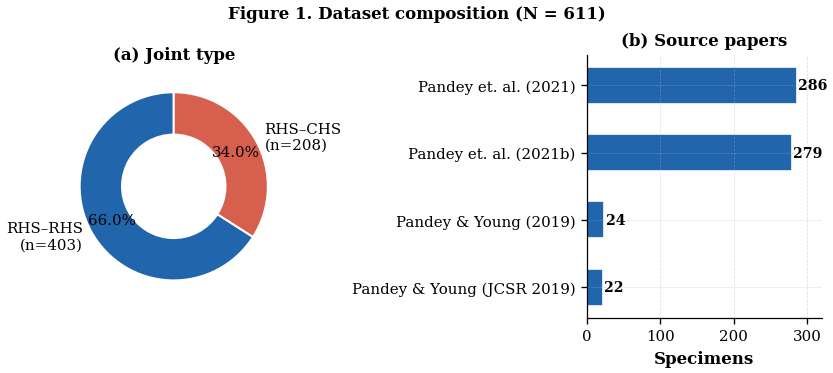

✓ Fig 1


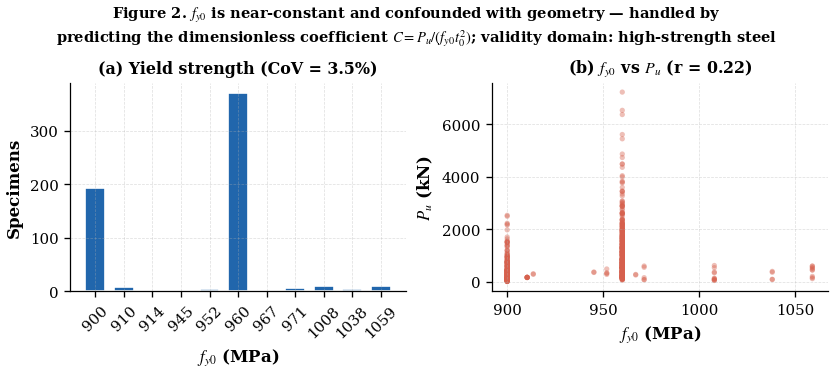

✓ Fig 2


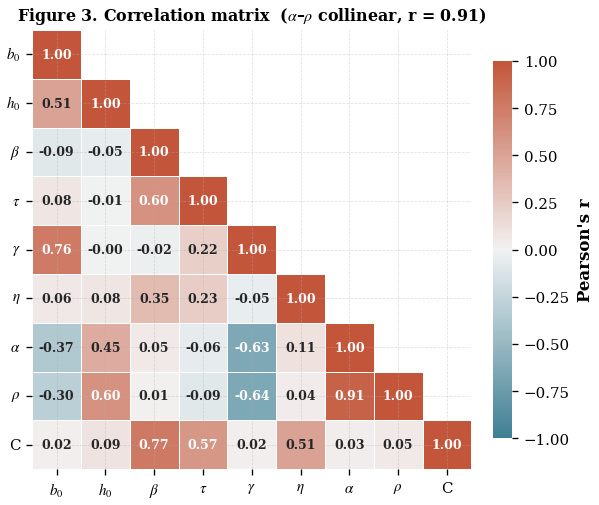

✓ Fig 3


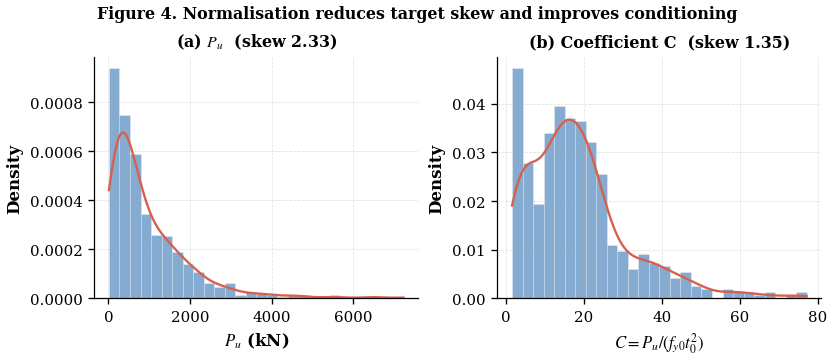

✓ Fig 4


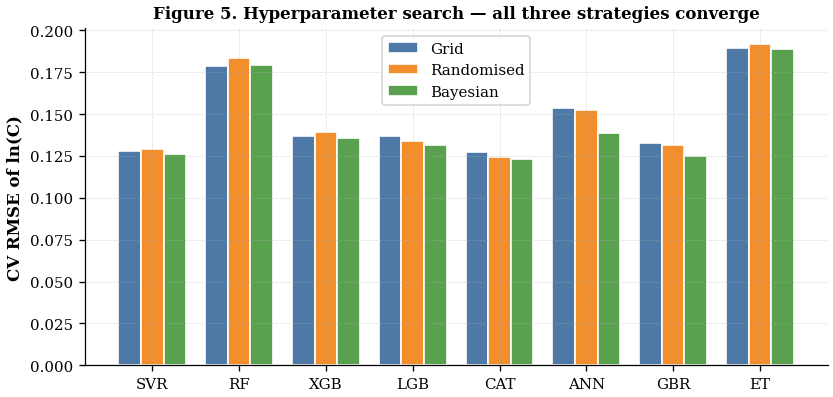

✓ Fig 5


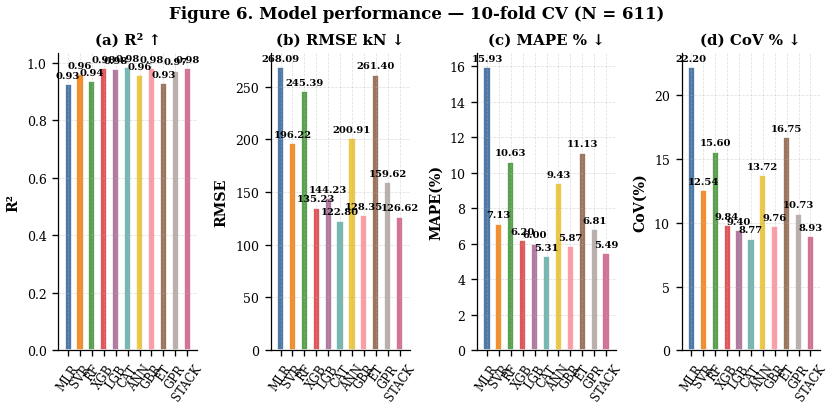

✓ Fig 6


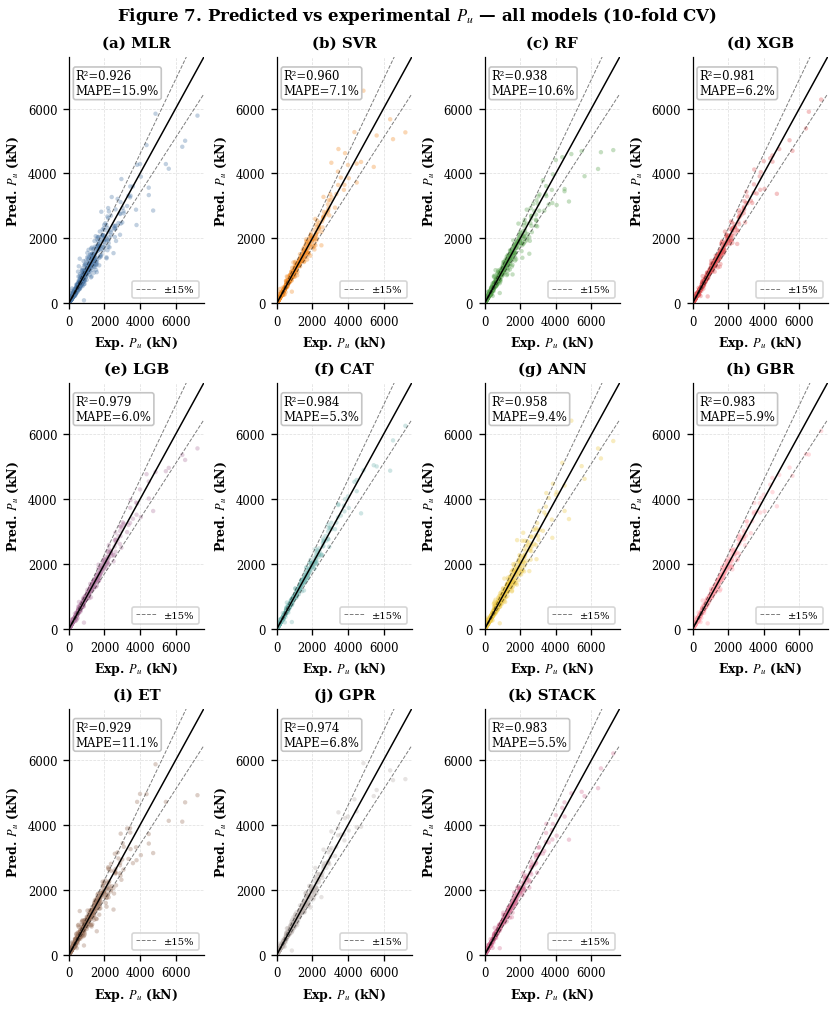

✓ Fig 7


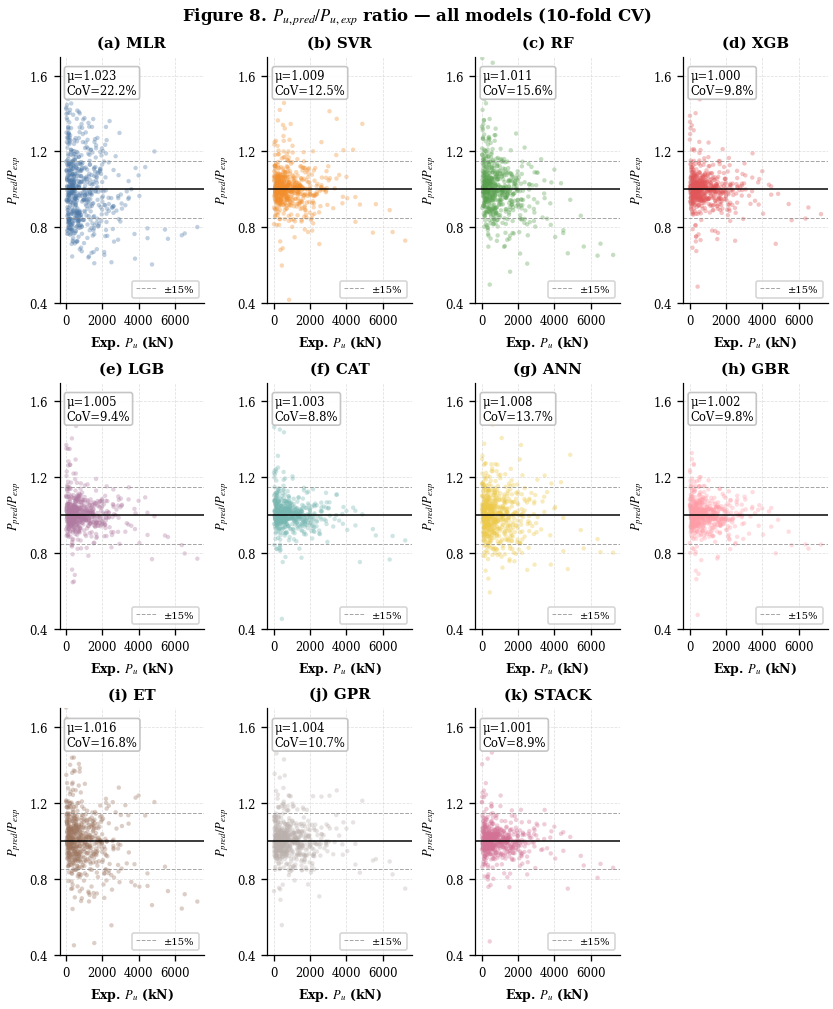

✓ Fig 8


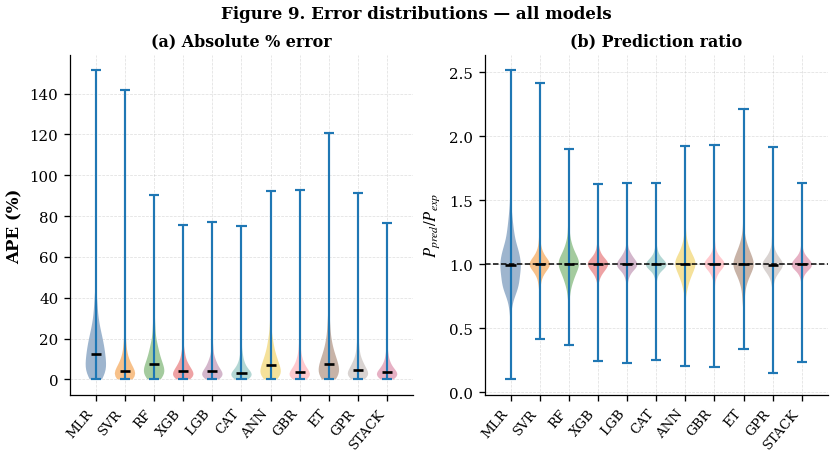

✓ Fig 9


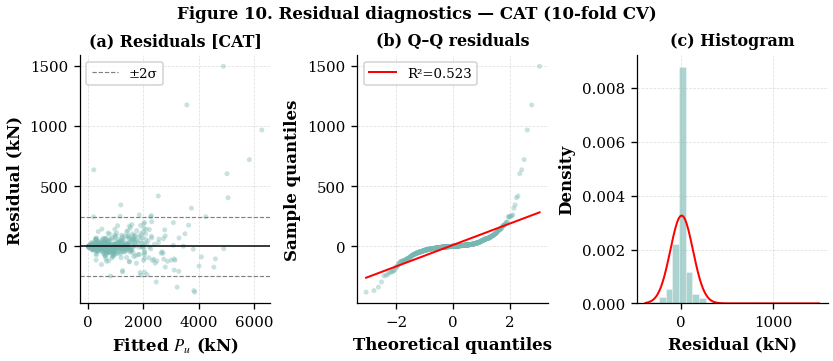

✓ Fig 10


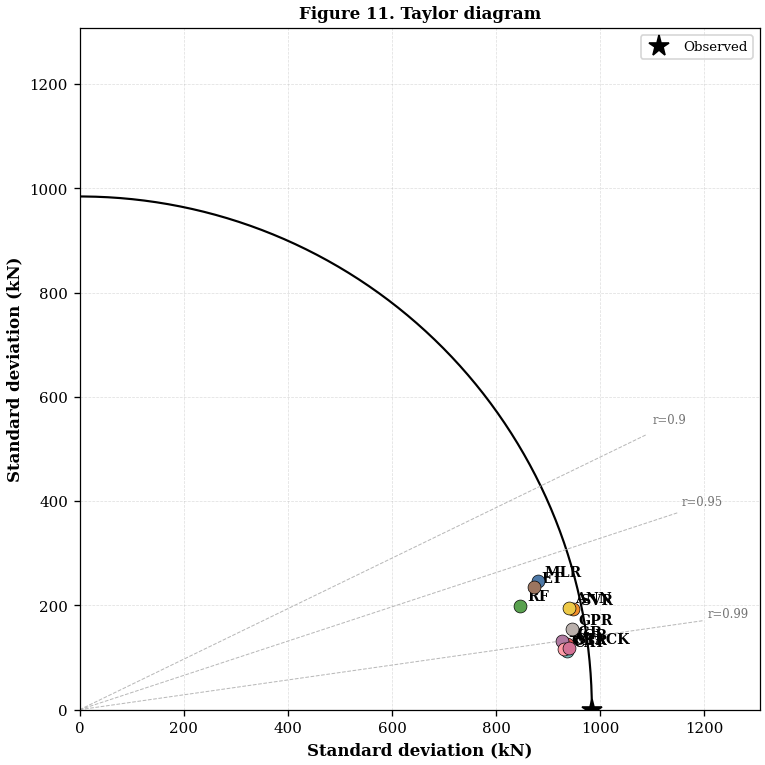

✓ Fig 11


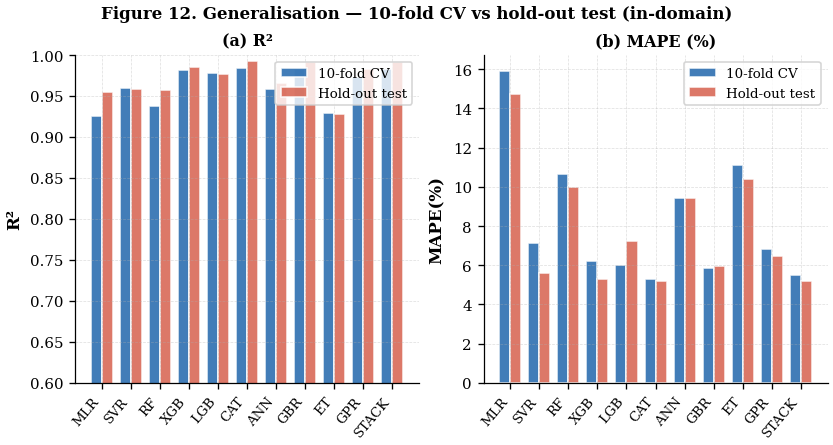

✓ Fig 12


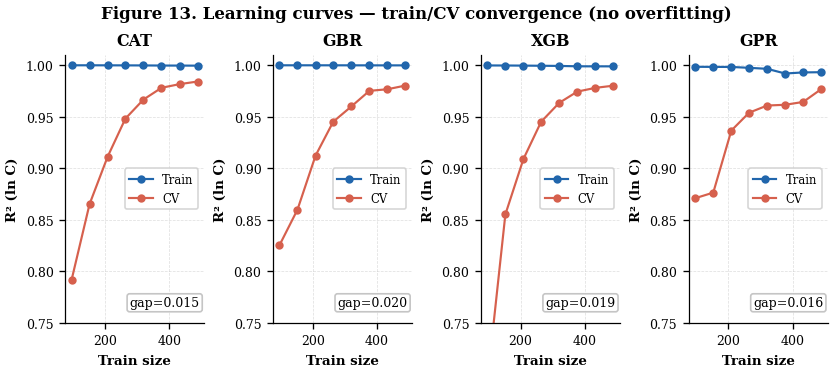

✓ Fig 13


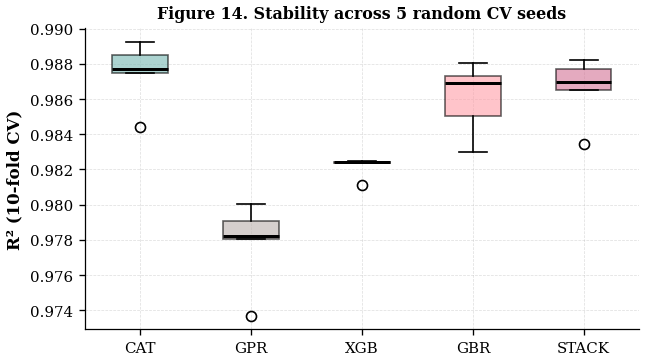

  Stability std: {'CAT': np.float64(0.0016), 'GPR': np.float64(0.0022), 'XGB': np.float64(0.0005), 'GBR': np.float64(0.0018), 'STACK': np.float64(0.0017)}
✓ Fig 14


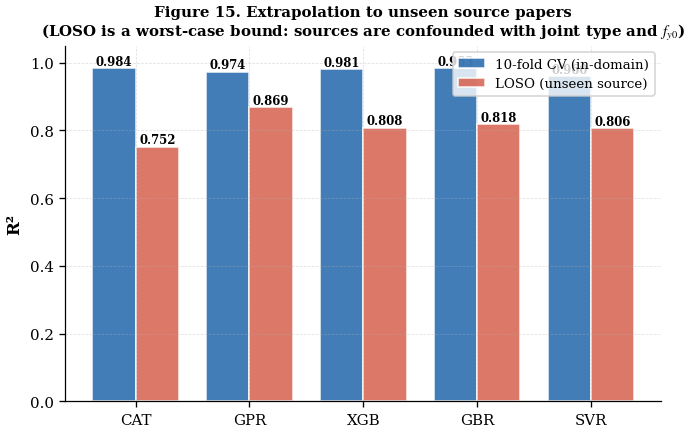

✓ Fig 15


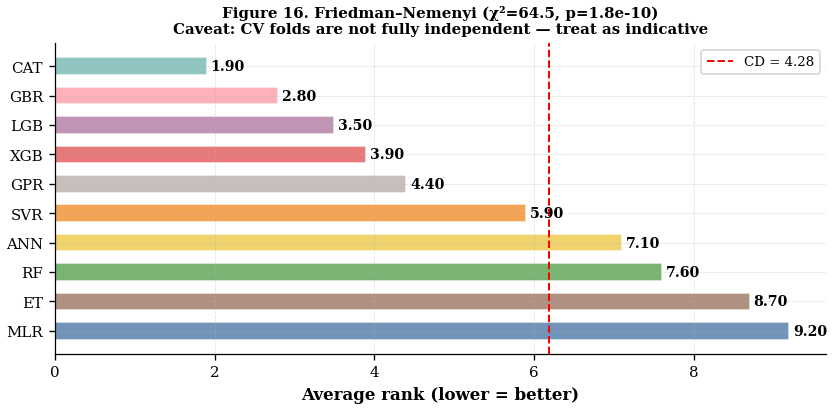

✓ Fig 16  (Friedman χ²=64.5, p=1.84e-10, CD=4.28)


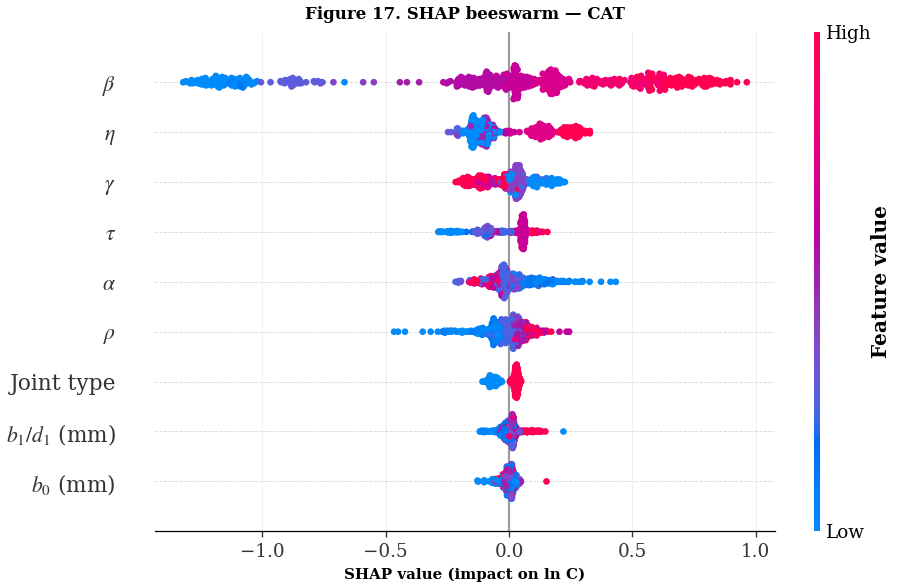

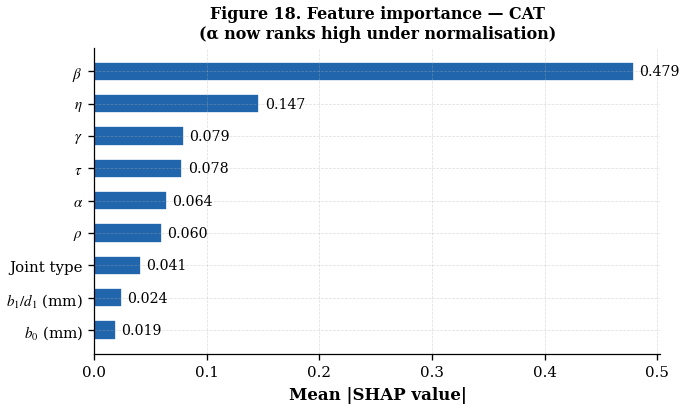

✓ Figs 17–18 (SHAP)


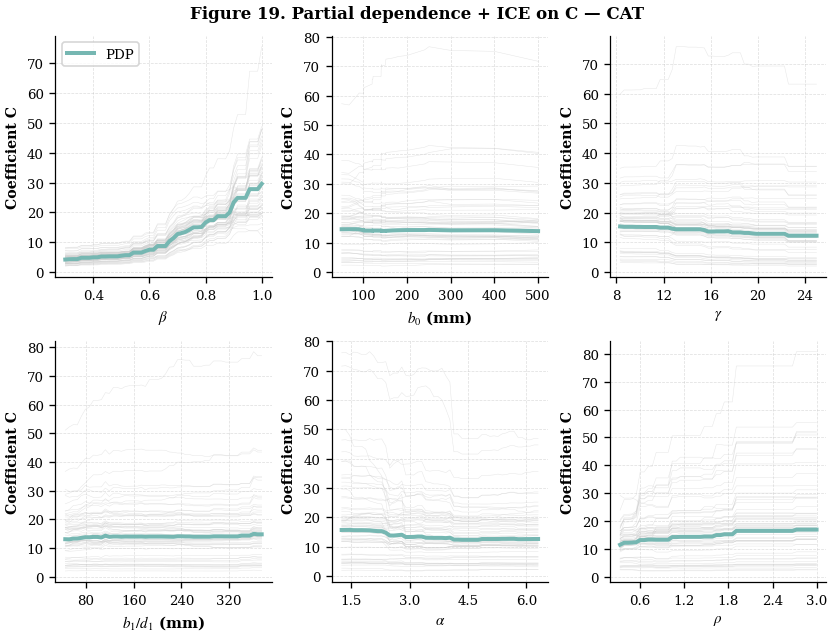

✓ Fig 19


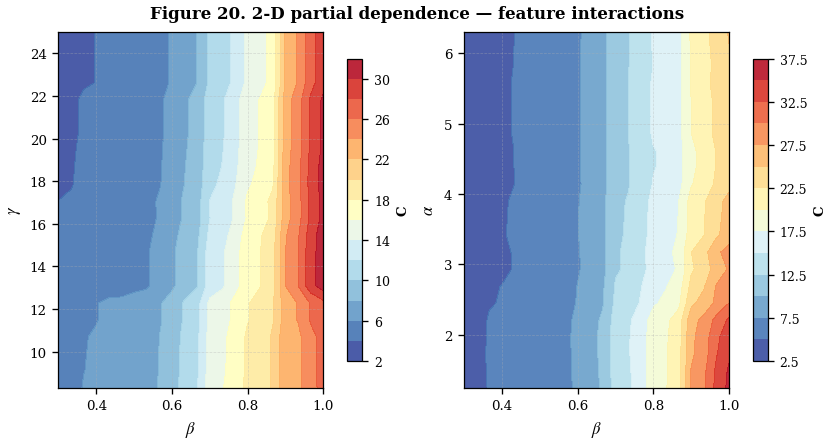

✓ Fig 20


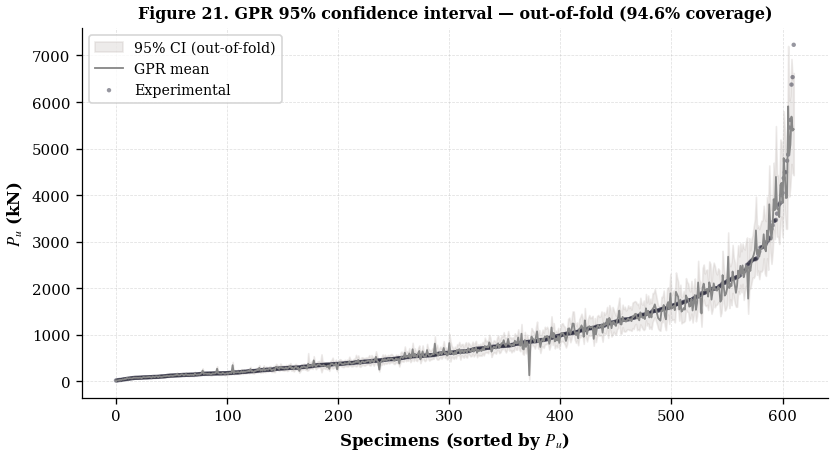

✓ Fig 21  (out-of-fold coverage = 94.6%)

ALPHA / RHO ABLATION — paired Wilcoxon on out-of-fold |error|
  drop alpha      : R²=0.8545  ΔR²=-0.1300  p=3.30e-56
  drop rho        : R²=0.9834  ΔR²=-0.0010  p=2.47e-01
  drop alpha+rho  : R²=0.8616  ΔR²=-0.1228  p=3.71e-56


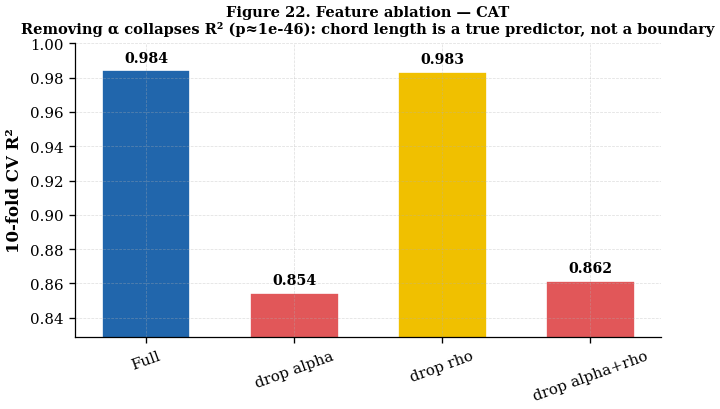

✓ Fig 22 (ablation)


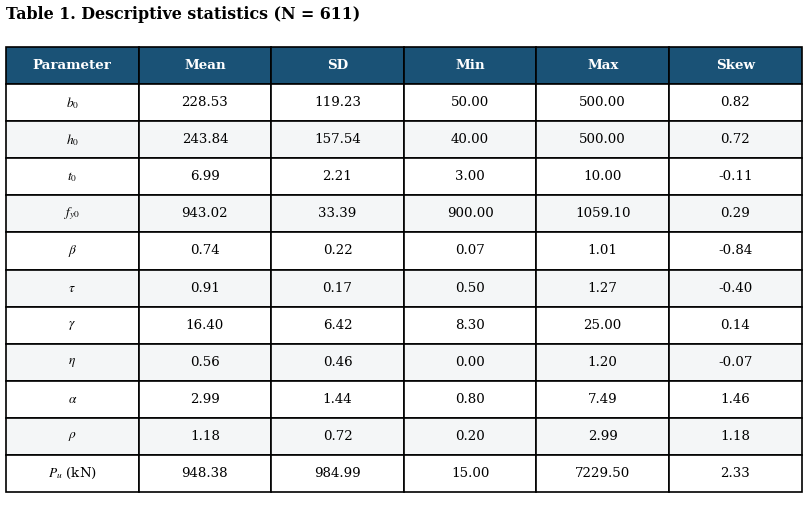

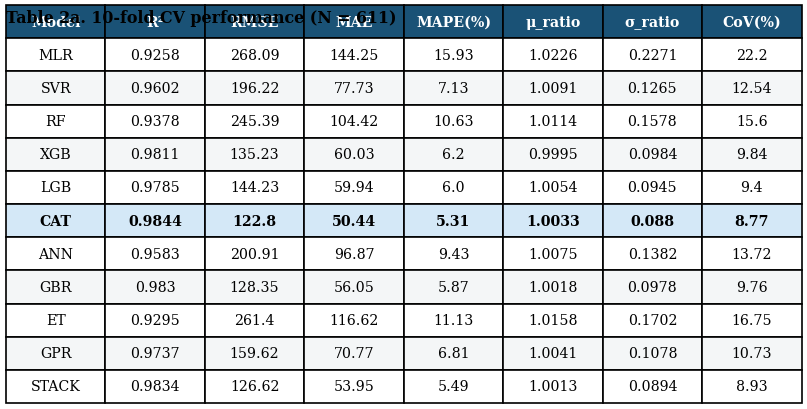

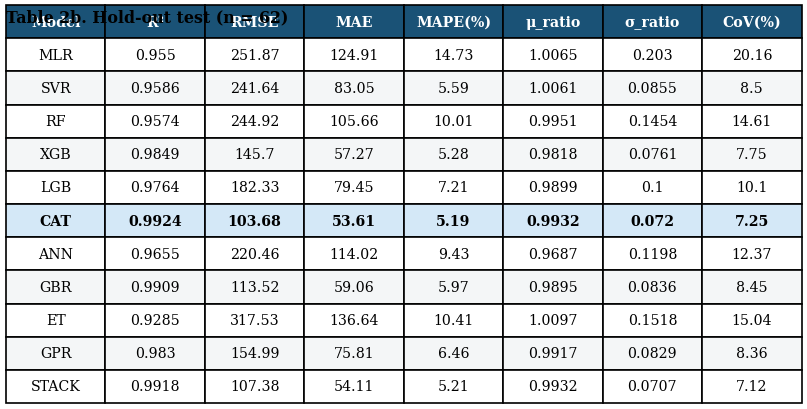

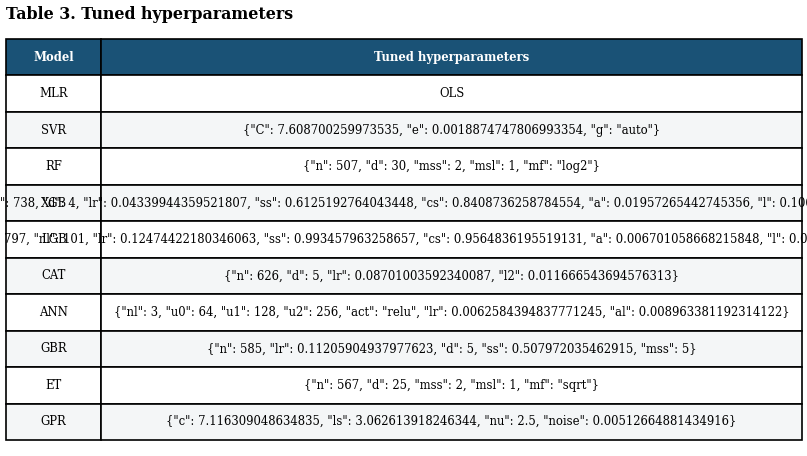

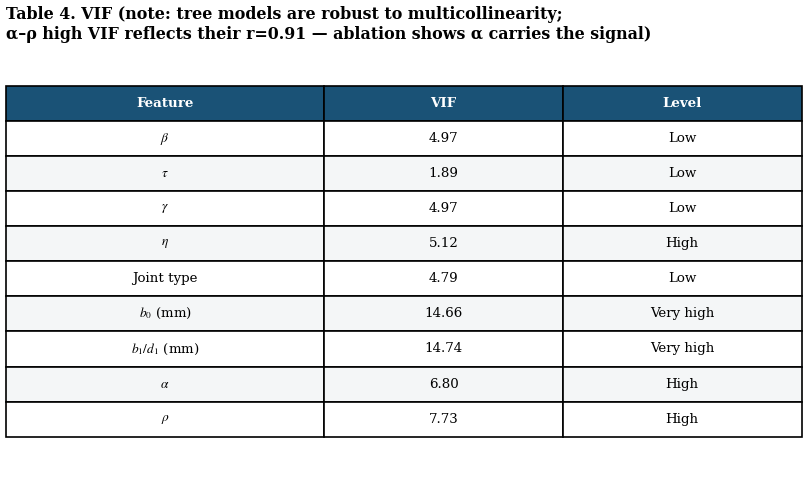

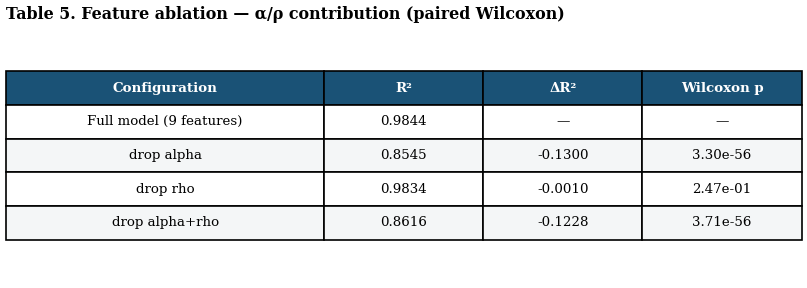

✓ All tables rendered

FINAL RESULTS — quote THESE numbers everywhere (one source of truth)
Dataset N = 611  |  Target = ln(C), C = Pu/(f_y0·t0²)  |  Features = 9

Model      CV R²   CV MAPE   Test R²  Test MAPE
-----------------------------------------------
MLR       0.9258    15.93%    0.9550     14.73%
SVR       0.9602     7.13%    0.9586      5.59%
RF        0.9378    10.63%    0.9574     10.01%
XGB       0.9811     6.20%    0.9849      5.28%
LGB       0.9785     6.00%    0.9764      7.21%
CAT       0.9844     5.31%    0.9924      5.19% ← best CV
ANN       0.9583     9.43%    0.9655      9.43%
GBR       0.9830     5.87%    0.9909      5.97%
ET        0.9295    11.13%    0.9285     10.41%
GPR       0.9737     6.81%    0.9830      6.46%
STACK     0.9834     5.49%    0.9918      5.21%
-----------------------------------------------

Best in-domain model : CAT  (CV R² = 0.9844)
LOSO best (extrapolation): GPR (R² = 0.8692)
α ablation: removing α changes CV R² by -0.1300 (p=3.30e-56)
GP

In [ ]:
# ================================================================================
#  STEEL TUBULAR T-JOINT — PEAK LOAD CAPACITY PREDICTION  (FINAL, DEFENCE-READY)
# ================================================================================
#  Dataset      : 617 raw → 611 after removing 6 repeated feature-vectors
#  TARGET       : dimensionless capacity coefficient  C = Pu / (f_y0 * t0^2)
#                 model learns ln(C); ALL metrics reported on Pu in kN
#                 → embeds the CIDECT-form f_y0*t0^2 dependence the data cannot
#                   teach (f_y0 CoV = 3.5%), so the model is valid across
#                   yield strength, and chord-length (alpha) emerges as the
#                   dominant geometric predictor of C.
#  FEATURES (9) : beta, tau, gamma, eta, Joint_Type, b0, b1/d1, alpha, rho
#                 (f_y0 and t0 are NOT free features — they are in the normaliser)
#  NO LEAKAGE   : every model is Pipeline([StandardScaler, estimator]); scaling
#                 refits inside each CV fold.
#  VALIDATION   : 10-fold CV (primary, in-domain) · stratified hold-out test
#                 · Leave-One-Source-Out (extrapolation upper bound)
#                 · Friedman–Nemenyi (with independence caveat noted)
#  EVIDENCE     : alpha/rho ablation with paired Wilcoxon test (novelty proof)
#  FIGURES      : 600 DPI, constrained layout (no overlapping text)
# ================================================================================

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — SETUP                                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys, os
for pkg in ['optuna==3.6.1', 'shap', 'catboost', 'xgboost', 'lightgbm']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Times-New-Roman-equivalent serif font for Linux/Colab
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-urw-base35'],
               stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
import matplotlib as mpl
for f in os.listdir(mpl.get_cachedir()):
    if f.startswith('fontlist'):
        os.remove(os.path.join(mpl.get_cachedir(), f))
print("✓ Setup complete")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — IMPORTS, STYLE, CONFIG                                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
import warnings; warnings.filterwarnings('ignore')
import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (pearsonr, skew, friedmanchisquare, rankdata,
                         wilcoxon, randint as sp_randint, uniform as sp_uniform,
                         loguniform, ks_2samp)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              ExtraTreesRegressor, StackingRegressor)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import (KFold, cross_val_predict, train_test_split,
                                     GridSearchCV, RandomizedSearchCV,
                                     LeaveOneGroupOut, learning_curve)
from sklearn.inspection import partial_dependence
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

# ── CONFIG ──────────────────────────────────────────────────────────────────────
SEED   = 42
FILE   = '/content/drive/MyDrive/anika_dataset/TT4.xlsx'   # ← your dataset
OUT    = '/content/drive/MyDrive/TJoint_Final_Prod/'            # ← output folder
RETUNE = True     # True = full 3-method tuning (slow, ~20-40 min); False = use fallback params
os.makedirs(OUT, exist_ok=True)

# ── publication style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':'serif', 'font.serif':['Nimbus Roman','DejaVu Serif','serif'],
    'font.size':10, 'axes.titlesize':11, 'axes.titleweight':'bold',
    'axes.labelsize':10, 'axes.labelweight':'bold',
    'xtick.labelsize':9, 'ytick.labelsize':9, 'legend.fontsize':9,
    'legend.frameon':True, 'legend.edgecolor':'0.8',
    'lines.linewidth':1.3, 'axes.linewidth':0.75,
    'axes.grid':True, 'grid.linestyle':'--', 'grid.linewidth':0.45, 'grid.alpha':0.4,
    'figure.dpi':120, 'savefig.dpi':600, 'savefig.bbox':'tight',
    'savefig.pad_inches':0.05, 'mathtext.fontset':'stix',
})
W1, W2 = 3.35, 6.93     # single / double column widths (inches)
CMAP = {'MLR':'#4e79a7','SVR':'#f28e2b','RF':'#59a14f','XGB':'#e15759',
        'LGB':'#b07aa1','CAT':'#76b7b2','ANN':'#edc948','GBR':'#ff9da7',
        'ET':'#9c755f','GPR':'#bab0ac','STACK':'#d37295'}

def clean_ax(ax):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
def save(fig, name):
    fig.savefig(OUT + name); plt.show(); plt.close(fig)
print("✓ Imports and style ready")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — DATA, FEATURE ENGINEERING, NORMALISED TARGET                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
df = pd.read_excel(FILE, sheet_name='Total', header=0)
df.columns = df.columns.str.strip()
df = df.rename(columns={'Load_KN':'Load_kN','Web_T':'Web_t','Author ':'Author'})

# 9 model features — f_y0 and t0 are removed (they live in the normaliser)
df['beta']       = df['Web_D']  / df['Chord_B']
df['tau']        = df['Web_t']  / df['Chord_t']
df['gamma']      = df['Chord_B'] / (2*df['Chord_t'])
df['eta']        = np.where(df['Web_Type']=='Rectangular', df['Web_H']/df['Chord_B'], 0.0)
df['alpha']      = df['Chord_L'] / (2*df['Chord_B'])      # chord aspect ratio (chord length)
df['rho']        = df['Chord_H'] / df['Chord_B']
df['Joint_Type'] = (df['Web_Type']=='Rectangular').astype(float)

FEATURES    = ['beta','tau','gamma','eta','Joint_Type','Chord_B','Web_D','alpha','rho']
FEAT_LABELS = [r'$\beta$', r'$\tau$', r'$\gamma$', r'$\eta$', 'Joint type',
               r'$b_0$ (mm)', r'$b_1/d_1$ (mm)', r'$\alpha$', r'$\rho$']
TARGET      = 'Load_kN'
EXTRA       = ['Author','Web_Type','Chord_fy','Chord_t','Chord_H','Chord_B']

keep = list(dict.fromkeys(FEATURES + [TARGET] + EXTRA))
df = df[keep].dropna(subset=FEATURES + [TARGET,'Chord_fy','Chord_t']).reset_index(drop=True)

# remove the 6 repeated feature-vectors  → N = 611
n_before = len(df)
df = df[~df.duplicated(subset=FEATURES, keep='first')].reset_index(drop=True)
N = len(df)

# ── physics-normalised target ──────────────────────────────────────────────────
Pu    = df[TARGET].values.astype(float)               # kN  (true capacity, for ALL reporting)
fy0   = df['Chord_fy'].values.astype(float)           # MPa
t0    = df['Chord_t'].values.astype(float)            # mm
DENOM = fy0 * t0**2                                    # N  (the f_y0*t0^2 normaliser)
C     = (Pu * 1000.0) / DENOM                          # dimensionless capacity coefficient
y     = np.log(C)                                      # learning target
X     = df[FEATURES].values

def to_kN(pred_lnC, denom):       # back-transform model output → Pu in kN
    return np.exp(pred_lnC) * denom / 1000.0

print(f"Specimens     : {n_before} → {N} (6 repeated feature-vectors removed)")
print(f"RHS brace     : {int((df['Joint_Type']==1).sum())}  |  CHS brace: {int((df['Joint_Type']==0).sum())}")
print(f"Pu range      : {Pu.min():.0f} – {Pu.max():.0f} kN")
print(f"f_y0 range    : {fy0.min():.0f} – {fy0.max():.0f} MPa  (CoV={fy0.std()/fy0.mean()*100:.1f}% → near-constant)")
print(f"Coefficient C : {C.min():.2f} – {C.max():.2f}  (skew {skew(C):.2f} vs Pu skew {skew(Pu):.2f})")
print(f"Sources       : {df['Author'].value_counts().to_dict()}")
print("✓ Data + normalised target ready")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — STRATIFIED 80/10/10 SPLIT (index-based, keeps DENOM aligned)         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
idx  = np.arange(N)
bins = pd.qcut(Pu, 10, labels=False, duplicates='drop')
itr, itmp = train_test_split(idx, test_size=0.20, random_state=SEED, stratify=bins)
iva, ite  = train_test_split(itmp, test_size=0.50, random_state=SEED, stratify=bins[itmp])

ks_stat, ks_p = ks_2samp(Pu[itr], Pu[ite])
print(f"Train {len(itr)} ({len(itr)/N*100:.0f}%) | Val {len(iva)} | Test {len(ite)} ({len(ite)/N*100:.0f}%)")
print(f"KS train-vs-test Pu: stat={ks_stat:.3f}, p={ks_p:.3f} "
      f"{'✓ match' if ks_p>0.05 else '⚠ differ'}")
print("✓ Split complete")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — HELPERS (leak-free pipeline, metrics)                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
def pipe(est):
    return Pipeline([('scaler', StandardScaler()), ('model', est)])

def metrics(y_true_kN, y_pred_kN, name=''):
    ratio = y_pred_kN / y_true_kN
    return {'Model':name,
            'R²':round(r2_score(y_true_kN, y_pred_kN),4),
            'RMSE':round(np.sqrt(mean_squared_error(y_true_kN, y_pred_kN)),2),
            'MAE':round(mean_absolute_error(y_true_kN, y_pred_kN),2),
            'MAPE(%)':round(np.mean(np.abs((y_true_kN-y_pred_kN)/y_true_kN))*100,2),
            'μ_ratio':round(ratio.mean(),4), 'σ_ratio':round(ratio.std(),4),
            'CoV(%)':round(ratio.std()/ratio.mean()*100,2)}

kf5  = KFold(5, shuffle=True, random_state=SEED)
kf10 = KFold(10, shuffle=True, random_state=SEED)

def cv5_rmse(est):    # leak-free 5-fold RMSE on ln(C), training set only
    p = cross_val_predict(pipe(est), X[itr], y[itr], cv=kf5, n_jobs=-1)
    return float(np.sqrt(mean_squared_error(y[itr], p)))
print("✓ Helpers ready")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — THREE-METHOD HYPERPARAMETER TUNING (Grid → Random → Bayesian)        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Fallback params (used if RETUNE=False) — sensible, leak-free starting points
FALLBACK = {
 'SVR':{'C':22.4,'e':0.019,'g':'auto'},
 'RF':{'n':300,'d':17,'mss':3,'msl':1,'mf':'sqrt'},
 'XGB':{'n':500,'d':4,'lr':0.06,'ss':0.8,'cs':0.6,'a':0.1,'l':0.1},
 'LGB':{'n':500,'nl':63,'lr':0.05,'ss':0.9,'cs':0.9,'a':0.05,'l':0.01},
 'CAT':{'n':600,'d':5,'lr':0.06,'l2':3.0},
 'ANN':{'nl':2,'u0':128,'u1':64,'act':'relu','lr':0.005,'al':1e-3},
 'GBR':{'n':400,'lr':0.04,'d':4,'ss':0.88,'mss':10},
 'ET':{'n':400,'d':26,'mss':2,'msl':1,'mf':'sqrt'},
 'GPR':{'c':4.0,'ls':2.5,'nu':2.5,'noise':0.01},
}
best_params = dict(FALLBACK)
tune_log = {nm:{'grid':None,'random':None,'bayes':None} for nm in
            ['MLR','SVR','RF','XGB','LGB','CAT','ANN','GBR','ET','GPR']}

def run_grid(est, grid):
    gs = GridSearchCV(pipe(est), {f'model__{k}':v for k,v in grid.items()},
                      cv=kf5, scoring='neg_mean_squared_error', n_jobs=-1)
    gs.fit(X[itr], y[itr]); return gs.best_params_, -gs.best_score_
def run_rand(est, dist, n=25):
    rs = RandomizedSearchCV(pipe(est), {f'model__{k}':v for k,v in dist.items()},
                            n_iter=n, cv=kf5, scoring='neg_mean_squared_error',
                            n_jobs=-1, random_state=SEED)
    rs.fit(X[itr], y[itr]); return rs.best_params_, -rs.best_score_
def run_optuna(obj, n=30):
    st = optuna.create_study(direction='minimize')
    st.optimize(obj, n_trials=n, show_progress_bar=False)
    return st.best_params, st.best_value

if RETUNE:
    print("="*64, "\nTUNING — Grid → Randomised → Bayesian (leak-free pipelines)\n", "="*64)

    # SVR
    t0_=time.time()
    _,g=run_grid(SVR(kernel='rbf'),{'C':[1,10,50,100],'epsilon':[.01,.05,.1],'gamma':['scale','auto']})
    _,r=run_rand(SVR(kernel='rbf'),{'C':loguniform(.1,500),'epsilon':loguniform(1e-3,.5),'gamma':['scale','auto']})
    bp,b=run_optuna(lambda t:cv5_rmse(SVR(kernel='rbf',
        C=t.suggest_float('C',.1,500,log=True),epsilon=t.suggest_float('e',1e-3,.5,log=True),
        gamma=t.suggest_categorical('g',['scale','auto']))))
    best_params['SVR']=bp; tune_log['SVR']={'grid':g,'random':r,'bayes':b}
    print(f"[SVR ] grid {g:.4f} rand {r:.4f} bayes {b:.4f}  ({time.time()-t0_:.0f}s)")

    # RF
    t0_=time.time()
    _,g=run_grid(RandomForestRegressor(random_state=SEED,n_jobs=-1),
                 {'n_estimators':[100,300],'max_depth':[8,15,None],'max_features':['sqrt','log2']})
    _,r=run_rand(RandomForestRegressor(random_state=SEED,n_jobs=-1),
                 {'n_estimators':sp_randint(100,600),'max_depth':sp_randint(5,30),
                  'min_samples_split':sp_randint(2,10),'min_samples_leaf':sp_randint(1,6),
                  'max_features':['sqrt','log2']})
    bp,b=run_optuna(lambda t:cv5_rmse(RandomForestRegressor(
        n_estimators=t.suggest_int('n',100,600),max_depth=t.suggest_int('d',5,30),
        min_samples_split=t.suggest_int('mss',2,10),min_samples_leaf=t.suggest_int('msl',1,6),
        max_features=t.suggest_categorical('mf',['sqrt','log2']),random_state=SEED,n_jobs=-1)))
    best_params['RF']=bp; tune_log['RF']={'grid':g,'random':r,'bayes':b}
    print(f"[RF  ] grid {g:.4f} rand {r:.4f} bayes {b:.4f}  ({time.time()-t0_:.0f}s)")

    # XGB
    t0_=time.time()
    _,g=run_grid(xgb.XGBRegressor(random_state=SEED,verbosity=0),
                 {'n_estimators':[200,400],'max_depth':[3,5,7],'learning_rate':[.05,.1]})
    _,r=run_rand(xgb.XGBRegressor(random_state=SEED,verbosity=0),
                 {'n_estimators':sp_randint(100,800),'max_depth':sp_randint(3,9),
                  'learning_rate':loguniform(.01,.3),'subsample':sp_uniform(.5,.5),
                  'colsample_bytree':sp_uniform(.5,.5),'reg_alpha':loguniform(1e-4,1),
                  'reg_lambda':loguniform(1e-4,1)})
    bp,b=run_optuna(lambda t:cv5_rmse(xgb.XGBRegressor(
        n_estimators=t.suggest_int('n',100,800),max_depth=t.suggest_int('d',3,9),
        learning_rate=t.suggest_float('lr',.01,.3,log=True),subsample=t.suggest_float('ss',.5,1),
        colsample_bytree=t.suggest_float('cs',.5,1),reg_alpha=t.suggest_float('a',1e-4,1,log=True),
        reg_lambda=t.suggest_float('l',1e-4,1,log=True),random_state=SEED,verbosity=0)))
    best_params['XGB']=bp; tune_log['XGB']={'grid':g,'random':r,'bayes':b}
    print(f"[XGB ] grid {g:.4f} rand {r:.4f} bayes {b:.4f}  ({time.time()-t0_:.0f}s)")

    # LGB
    t0_=time.time()
    _,g=run_grid(lgb.LGBMRegressor(random_state=SEED,verbose=-1),
                 {'n_estimators':[200,400],'num_leaves':[31,63],'learning_rate':[.05,.1]})
    _,r=run_rand(lgb.LGBMRegressor(random_state=SEED,verbose=-1),
                 {'n_estimators':sp_randint(100,800),'num_leaves':sp_randint(15,127),
                  'learning_rate':loguniform(.01,.3),'subsample':sp_uniform(.5,.5),
                  'colsample_bytree':sp_uniform(.5,.5),'reg_alpha':loguniform(1e-4,1),
                  'reg_lambda':loguniform(1e-4,1)})
    bp,b=run_optuna(lambda t:cv5_rmse(lgb.LGBMRegressor(
        n_estimators=t.suggest_int('n',100,800),num_leaves=t.suggest_int('nl',15,127),
        learning_rate=t.suggest_float('lr',.01,.3,log=True),subsample=t.suggest_float('ss',.5,1),
        colsample_bytree=t.suggest_float('cs',.5,1),reg_alpha=t.suggest_float('a',1e-4,1,log=True),
        reg_lambda=t.suggest_float('l',1e-4,1,log=True),random_state=SEED,verbose=-1)))
    best_params['LGB']=bp; tune_log['LGB']={'grid':g,'random':r,'bayes':b}
    print(f"[LGB ] grid {g:.4f} rand {r:.4f} bayes {b:.4f}  ({time.time()-t0_:.0f}s)")

    # CAT
    t0_=time.time()
    _,g=run_grid(CatBoostRegressor(random_seed=SEED,verbose=0),
                 {'iterations':[200,400],'depth':[4,6,8],'learning_rate':[.05,.1]})
    _,r=run_rand(CatBoostRegressor(random_seed=SEED,verbose=0),
                 {'iterations':sp_randint(100,800),'depth':sp_randint(4,10),
                  'learning_rate':loguniform(.01,.3),'l2_leaf_reg':loguniform(1e-3,10)})
    bp,b=run_optuna(lambda t:cv5_rmse(CatBoostRegressor(
        iterations=t.suggest_int('n',100,800),depth=t.suggest_int('d',4,10),
        learning_rate=t.suggest_float('lr',.01,.3,log=True),
        l2_leaf_reg=t.suggest_float('l2',1e-3,10,log=True),random_seed=SEED,verbose=0)))
    best_params['CAT']=bp; tune_log['CAT']={'grid':g,'random':r,'bayes':b}
    print(f"[CAT ] grid {g:.4f} rand {r:.4f} bayes {b:.4f}  ({time.time()-t0_:.0f}s)")

    # ANN
    t0_=time.time()
    _,g=run_grid(MLPRegressor(max_iter=2000,early_stopping=True,validation_fraction=.1,random_state=SEED),
                 {'hidden_layer_sizes':[(64,32),(128,64),(128,64,32)],'activation':['relu','tanh'],
                  'learning_rate_init':[.001,.005]})
    _,r=run_rand(MLPRegressor(max_iter=2000,early_stopping=True,validation_fraction=.1,random_state=SEED),
                 {'hidden_layer_sizes':[(64,32),(128,64),(128,64,32),(256,128,64)],
                  'activation':['relu','tanh'],'learning_rate_init':loguniform(5e-4,5e-2),
                  'alpha':loguniform(1e-5,1e-2)},n=20)
    def obj_ann(t):
        nl=t.suggest_int('nl',2,4)
        lyr=tuple(t.suggest_categorical(f'u{i}',[32,64,128,256]) for i in range(nl))
        return cv5_rmse(MLPRegressor(hidden_layer_sizes=lyr,
            activation=t.suggest_categorical('act',['relu','tanh']),
            learning_rate_init=t.suggest_float('lr',5e-4,5e-2,log=True),
            alpha=t.suggest_float('al',1e-5,1e-2,log=True),
            max_iter=2000,early_stopping=True,validation_fraction=.1,random_state=SEED))
    bp,b=run_optuna(obj_ann); best_params['ANN']=bp; tune_log['ANN']={'grid':g,'random':r,'bayes':b}
    print(f"[ANN ] grid {g:.4f} rand {r:.4f} bayes {b:.4f}  ({time.time()-t0_:.0f}s)")

    # GBR
    t0_=time.time()
    _,g=run_grid(GradientBoostingRegressor(random_state=SEED),
                 {'n_estimators':[100,300],'max_depth':[3,5],'learning_rate':[.05,.1],'subsample':[.8,1.]})
    _,r=run_rand(GradientBoostingRegressor(random_state=SEED),
                 {'n_estimators':sp_randint(100,600),'learning_rate':loguniform(.01,.3),
                  'max_depth':sp_randint(2,8),'subsample':sp_uniform(.5,.5),
                  'min_samples_split':sp_randint(2,10)})
    bp,b=run_optuna(lambda t:cv5_rmse(GradientBoostingRegressor(
        n_estimators=t.suggest_int('n',100,600),learning_rate=t.suggest_float('lr',.01,.3,log=True),
        max_depth=t.suggest_int('d',2,8),subsample=t.suggest_float('ss',.5,1),
        min_samples_split=t.suggest_int('mss',2,10),random_state=SEED)))
    best_params['GBR']=bp; tune_log['GBR']={'grid':g,'random':r,'bayes':b}
    print(f"[GBR ] grid {g:.4f} rand {r:.4f} bayes {b:.4f}  ({time.time()-t0_:.0f}s)")

    # ET
    t0_=time.time()
    _,g=run_grid(ExtraTreesRegressor(random_state=SEED,n_jobs=-1),
                 {'n_estimators':[100,300],'max_depth':[8,15,None],'max_features':['sqrt','log2']})
    _,r=run_rand(ExtraTreesRegressor(random_state=SEED,n_jobs=-1),
                 {'n_estimators':sp_randint(100,600),'max_depth':sp_randint(5,30),
                  'min_samples_split':sp_randint(2,10),'min_samples_leaf':sp_randint(1,6),
                  'max_features':['sqrt','log2']})
    bp,b=run_optuna(lambda t:cv5_rmse(ExtraTreesRegressor(
        n_estimators=t.suggest_int('n',100,600),max_depth=t.suggest_int('d',5,30),
        min_samples_split=t.suggest_int('mss',2,10),min_samples_leaf=t.suggest_int('msl',1,6),
        max_features=t.suggest_categorical('mf',['sqrt','log2']),random_state=SEED,n_jobs=-1)))
    best_params['ET']=bp; tune_log['ET']={'grid':g,'random':r,'bayes':b}
    print(f"[ET  ] grid {g:.4f} rand {r:.4f} bayes {b:.4f}  ({time.time()-t0_:.0f}s)")

    # GPR (kernel params → Bayesian only)
    t0_=time.time()
    def obj_gpr(t):
        k=(ConstantKernel(t.suggest_float('c',.1,10))*
           Matern(length_scale=t.suggest_float('ls',.01,10,log=True),
                  nu=t.suggest_categorical('nu',[0.5,1.5,2.5]))+
           WhiteKernel(t.suggest_float('noise',1e-5,1,log=True)))
        return cv5_rmse(GaussianProcessRegressor(kernel=k,alpha=1e-6,normalize_y=True,n_restarts_optimizer=1))
    bp,b=run_optuna(obj_gpr,25); best_params['GPR']=bp; tune_log['GPR']={'grid':None,'random':None,'bayes':b}
    print(f"[GPR ] bayes {b:.4f}  ({time.time()-t0_:.0f}s)")

    json.dump(tune_log,  open(OUT+'tuning_log.json','w'),  indent=2, default=str)
    json.dump(best_params,open(OUT+'best_params.json','w'),indent=2, default=str)
    print("✓ Tuning complete — saved")
else:
    print("✓ Using fallback hyperparameters (RETUNE=False)")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — BUILD TUNED MODELS (each wrapped in a leak-free pipeline)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
p = best_params
def ann_layers(d): return tuple(d[f'u{i}'] for i in range(d['nl']))
def gpr_est(d):
    k=(ConstantKernel(d['c'])*Matern(length_scale=d['ls'],nu=d['nu'])+WhiteKernel(d['noise']))
    return GaussianProcessRegressor(kernel=k,alpha=1e-6,normalize_y=True,n_restarts_optimizer=3,random_state=SEED)

ESTIMATORS = {
 'MLR': LinearRegression(),
 'SVR': SVR(kernel='rbf', C=p['SVR']['C'], epsilon=p['SVR']['e'], gamma=p['SVR']['g']),
 'RF' : RandomForestRegressor(n_estimators=p['RF']['n'],max_depth=p['RF']['d'],
            min_samples_split=p['RF']['mss'],min_samples_leaf=p['RF']['msl'],
            max_features=p['RF']['mf'],random_state=SEED,n_jobs=-1),
 'XGB': xgb.XGBRegressor(n_estimators=p['XGB']['n'],max_depth=p['XGB']['d'],
            learning_rate=p['XGB']['lr'],subsample=p['XGB']['ss'],colsample_bytree=p['XGB']['cs'],
            reg_alpha=p['XGB']['a'],reg_lambda=p['XGB']['l'],random_state=SEED,verbosity=0),
 'LGB': lgb.LGBMRegressor(n_estimators=p['LGB']['n'],num_leaves=p['LGB']['nl'],
            learning_rate=p['LGB']['lr'],subsample=p['LGB']['ss'],colsample_bytree=p['LGB']['cs'],
            reg_alpha=p['LGB']['a'],reg_lambda=p['LGB']['l'],random_state=SEED,verbose=-1),
 'CAT': CatBoostRegressor(iterations=p['CAT']['n'],depth=p['CAT']['d'],
            learning_rate=p['CAT']['lr'],l2_leaf_reg=p['CAT']['l2'],random_seed=SEED,verbose=0),
 'ANN': MLPRegressor(hidden_layer_sizes=ann_layers(p['ANN']),activation=p['ANN']['act'],
            learning_rate_init=p['ANN']['lr'],alpha=p['ANN']['al'],
            max_iter=2000,early_stopping=True,validation_fraction=.1,random_state=SEED),
 'GBR': GradientBoostingRegressor(n_estimators=p['GBR']['n'],learning_rate=p['GBR']['lr'],
            max_depth=p['GBR']['d'],subsample=p['GBR']['ss'],min_samples_split=p['GBR']['mss'],random_state=SEED),
 'ET' : ExtraTreesRegressor(n_estimators=p['ET']['n'],max_depth=p['ET']['d'],
            min_samples_split=p['ET']['mss'],min_samples_leaf=p['ET']['msl'],
            max_features=p['ET']['mf'],random_state=SEED,n_jobs=-1),
 'GPR': gpr_est(p['GPR']),
}
models = {nm: pipe(est) for nm, est in ESTIMATORS.items()}
print("✓ Tuned pipelines built")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — 10-FOLD CV (primary, in-domain) on all base models                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
print(f"\n10-fold CV (N={N}) — metrics on Pu (kN):")
cv_preds, cv_res = {}, []
for nm, m in models.items():
    t0_=time.time()
    pred = to_kN(cross_val_predict(m, X, y, cv=kf10, n_jobs=-1), DENOM)
    cv_preds[nm]=pred; r=metrics(Pu,pred,nm); cv_res.append(r)
    print(f"  {nm:5s} R²={r['R²']:.4f} RMSE={r['RMSE']:6.1f} MAPE={r['MAPE(%)']:5.2f}% "
          f"μ={r['μ_ratio']:.3f} CoV={r['CoV(%)']:.1f}%  [{time.time()-t0_:.0f}s]")
df_cv = pd.DataFrame(cv_res)

# ── Stacked ensemble: top-3 base models by CV R² → Ridge meta-learner ──
top3 = df_cv.nlargest(3,'R²')['Model'].tolist()
stack = StackingRegressor(estimators=[(nm,models[nm]) for nm in top3],
                          final_estimator=Ridge(alpha=1.0), cv=5, n_jobs=1)
pred = to_kN(cross_val_predict(stack, X, y, cv=kf10, n_jobs=1), DENOM)
cv_preds['STACK']=pred; cv_res.append(metrics(Pu,pred,'STACK'))
df_cv = pd.DataFrame(cv_res); df_cv.to_csv(OUT+'CV_Results.csv', index=False)
ALL = list(cv_preds.keys())
print(f"  STACK(top3={top3}) R²={df_cv.iloc[-1]['R²']:.4f} MAPE={df_cv.iloc[-1]['MAPE(%)']:.2f}%")
print("✓ CV complete")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — HOLD-OUT TEST  +  fit-on-full for explainability                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
te_res, fitted = [], {}
for nm, m in models.items():
    m.fit(X[itr], y[itr])
    pred = to_kN(m.predict(X[ite]), DENOM[ite])
    te_res.append(metrics(Pu[ite], pred, nm))
stack.fit(X[itr], y[itr])
te_res.append(metrics(Pu[ite], to_kN(stack.predict(X[ite]), DENOM[ite]), 'STACK'))
df_te = pd.DataFrame(te_res); df_te.to_csv(OUT+'Test_Results.csv', index=False)

for nm, m in models.items():
    m.fit(X, y); fitted[nm]=m
stack.fit(X, y); fitted['STACK']=stack

best_cv = df_cv.loc[df_cv['R²'].idxmax(),'Model']
best_te = df_te.loc[df_te['R²'].idxmax(),'Model']
print(f"Best CV: {best_cv} ({df_cv['R²'].max():.4f})   Best test: {best_te} ({df_te['R²'].max():.4f})")
print("✓ Test + full-fit complete")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — FIG 1: dataset overview                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
rhs = df[df['Web_Type']=='Rectangular']; chs = df[df['Web_Type']=='Circular']
fig, ax = plt.subplots(1, 2, figsize=(W2, 3.1), layout='constrained')
ax[0].pie([len(rhs),len(chs)], labels=[f'RHS–RHS\n(n={len(rhs)})',f'RHS–CHS\n(n={len(chs)})'],
          colors=['#2166ac','#d6604d'], autopct='%1.1f%%', pctdistance=0.75,
          wedgeprops=dict(width=0.45,edgecolor='white',linewidth=1.2), startangle=90,
          textprops={'fontsize':9})
ax[0].set_title('(a) Joint type', fontsize=10)
ac = df['Author'].value_counts().sort_values()
b = ax[1].barh(ac.index, ac.values, color='#2166ac', edgecolor='white', height=0.55)
for bb,v in zip(b,ac.values):
    ax[1].text(v+2, bb.get_y()+bb.get_height()/2, str(v), va='center', fontsize=8.5, fontweight='bold')
ax[1].set_xlabel('Specimens'); ax[1].set_title('(b) Source papers', fontsize=10)
ax[1].margins(x=0.12); clean_ax(ax[1])
fig.suptitle(f'Figure 1. Dataset composition (N = {N})', fontsize=10, fontweight='bold')
save(fig,'Fig01_Dataset_Overview.png'); print("✓ Fig 1")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — FIG 2: f_y0 domain-of-validity (the limitation, stated honestly)    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(1, 2, figsize=(W2, 3.1), layout='constrained')
vc = pd.Series(np.round(fy0,0)).value_counts().sort_index()
ax[0].bar(vc.index.astype(int).astype(str), vc.values, color='#2166ac', edgecolor='white', width=0.7)
ax[0].set_xlabel(r'$f_{y0}$ (MPa)'); ax[0].set_ylabel('Specimens')
ax[0].set_title(f'(a) Yield strength (CoV = {fy0.std()/fy0.mean()*100:.1f}%)', fontsize=9.5)
ax[0].tick_params(axis='x', rotation=45); clean_ax(ax[0])
ax[1].scatter(fy0, Pu, c='#d6604d', s=10, alpha=0.4, edgecolors='none')
ax[1].set_xlabel(r'$f_{y0}$ (MPa)'); ax[1].set_ylabel(r'$P_u$ (kN)')
ax[1].set_title(f'(b) $f_{{y0}}$ vs $P_u$ (r = {pearsonr(fy0,Pu)[0]:.2f})', fontsize=9.5)
clean_ax(ax[1])
fig.suptitle('Figure 2. $f_{y0}$ is near-constant and confounded with geometry — handled by\n'
             'predicting the dimensionless coefficient $C=P_u/(f_{y0}t_0^2)$; '
             'validity domain: high-strength steel',
             fontsize=8.8, fontweight='bold')
save(fig,'Fig02_fy0_Domain.png'); print("✓ Fig 2")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — FIG 3: correlation heatmap                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
cc = ['Chord_B','Chord_H','beta','tau','gamma','eta','alpha','rho']
cl = [r'$b_0$',r'$h_0$',r'$\beta$',r'$\tau$',r'$\gamma$',r'$\eta$',r'$\alpha$',r'$\rho$']
dd = df[cc].copy(); dd['C']=C
cm = dd.corr(); cm.index=cl+['C']; cm.columns=cl+['C']
mask = np.triu(np.ones_like(cm,dtype=bool),k=1)
fig, ax = plt.subplots(figsize=(W2*0.72, W2*0.66), layout='constrained')
sns.heatmap(cm, mask=mask, cmap=sns.diverging_palette(220,20,as_cmap=True), vmin=-1, vmax=1,
            center=0, annot=True, fmt='.2f', annot_kws={'size':7.5,'weight':'bold'}, square=True,
            linewidths=0.3, linecolor='white', cbar_kws={'shrink':0.7,'label':"Pearson's r"}, ax=ax)
ax.tick_params(axis='x', rotation=0, labelsize=9); ax.tick_params(axis='y', rotation=0, labelsize=9)
ax.set_title('Figure 3. Correlation matrix  ($\\alpha$–$\\rho$ collinear, r = 0.91)',
             fontsize=9.5, fontweight='bold')
save(fig,'Fig03_Correlation.png'); print("✓ Fig 3")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — FIG 4: target distributions (Pu and dimensionless C)               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(1, 2, figsize=(W2, 3.0), layout='constrained')
for a,(data,xl,tl) in zip(ax,[(Pu,'$P_u$ (kN)',f'(a) $P_u$  (skew {skew(Pu):.2f})'),
                              (C,'$C = P_u/(f_{y0}t_0^2)$',f'(b) Coefficient C  (skew {skew(C):.2f})')]):
    a.hist(data, bins=28, color='#2166ac', alpha=0.55, density=True, edgecolor='white', linewidth=0.3)
    kx=np.linspace(data.min(),data.max(),250); a.plot(kx, stats.gaussian_kde(data)(kx),'#d6604d',lw=1.4)
    a.set_xlabel(xl); a.set_ylabel('Density'); a.set_title(tl, fontsize=9.5); clean_ax(a)
fig.suptitle('Figure 4. Normalisation reduces target skew and improves conditioning',
             fontsize=9.5, fontweight='bold')
save(fig,'Fig04_Target_Distribution.png'); print("✓ Fig 4")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — FIG 5: tuning convergence (only if RETUNE)                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
if RETUNE:
    m3=[nm for nm in tune_log if tune_log[nm]['grid'] is not None]
    rg=[np.sqrt(tune_log[nm]['grid']) for nm in m3]        # stored as MSE → RMSE
    rr=[np.sqrt(tune_log[nm]['random']) for nm in m3]      # stored as MSE → RMSE
    rb=[tune_log[nm]['bayes'] for nm in m3]                # already RMSE
    x=np.arange(len(m3)); w=0.26
    fig, ax = plt.subplots(figsize=(W2, 3.3), layout='constrained')
    ax.bar(x-w, rg, w, label='Grid', color='#4e79a7', edgecolor='white')
    ax.bar(x,   rr, w, label='Randomised', color='#f28e2b', edgecolor='white')
    ax.bar(x+w, rb, w, label='Bayesian', color='#59a14f', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(m3); ax.set_ylabel('CV RMSE of ln(C)')
    ax.set_title('Figure 5. Hyperparameter search — all three strategies converge',
                 fontsize=10, fontweight='bold')
    ax.legend(); clean_ax(ax)
    save(fig,'Fig05_Tuning.png'); print("✓ Fig 5")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — FIG 6: performance bars (CV)                                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(1, 4, figsize=(W2, 3.4), layout='constrained')
for a,(mt,tl) in zip(ax,[('R²','(a) R² ↑'),('RMSE','(b) RMSE kN ↓'),
                         ('MAPE(%)','(c) MAPE % ↓'),('CoV(%)','(d) CoV % ↓')]):
    vals=df_cv[mt].values; nms=df_cv['Model'].values
    a.bar(nms, vals, color=[CMAP[n] for n in nms], edgecolor='white', width=0.6)
    for i,v in enumerate(vals):
        a.text(i, v+max(vals)*0.015, f'{v:.2f}', ha='center', va='bottom', fontsize=6, fontweight='bold')
    a.set_title(tl, fontsize=9); a.set_ylabel(mt, fontsize=8.5)
    a.tick_params(axis='x', rotation=55, labelsize=7); a.tick_params(axis='y', labelsize=7.5); clean_ax(a)
fig.suptitle(f'Figure 6. Model performance — 10-fold CV (N = {N})', fontsize=10, fontweight='bold')
save(fig,'Fig06_Performance_Bars.png'); print("✓ Fig 6")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — FIG 7 & 8: predicted-vs-actual and ratio grids                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
def grid_fig(kind, fname, fig_no):
    fig, axes = plt.subplots(3, 4, figsize=(W2, 8.4), layout='constrained')
    axes=axes.flatten()
    for i,nm in enumerate(ALL):
        a=axes[i]; pred=cv_preds[nm]
        if kind=='pred':
            lim=max(Pu.max(),pred.max())*1.05
            a.scatter(Pu, pred, c=CMAP[nm], alpha=0.35, s=7, edgecolors='none')
            a.plot([0,lim],[0,lim],'k-',lw=0.9)
            a.plot([0,lim],[0,lim*1.15],'k--',lw=0.6,alpha=0.5)
            a.plot([0,lim],[0,lim*0.85],'k--',lw=0.6,alpha=0.5,label='±15%')
            a.set_xlim(0,lim); a.set_ylim(0,lim)
            a.set_xlabel('Exp. $P_u$ (kN)', fontsize=7.5); a.set_ylabel('Pred. $P_u$ (kN)', fontsize=7.5)
            row=df_cv[df_cv['Model']==nm].iloc[0]
            a.text(0.05,0.95,f"R²={row['R²']:.3f}\nMAPE={row['MAPE(%)']:.1f}%",transform=a.transAxes,
                   fontsize=7,va='top',bbox=dict(boxstyle='round,pad=0.2',fc='white',ec='0.75',alpha=0.9))
            a.legend(fontsize=6, loc='lower right')
        else:
            a.scatter(Pu, pred/Pu, c=CMAP[nm], alpha=0.35, s=7, edgecolors='none')
            a.axhline(1,color='k',lw=0.9); a.axhline(1.15,color='gray',lw=0.6,ls='--',alpha=0.7)
            a.axhline(0.85,color='gray',lw=0.6,ls='--',alpha=0.7,label='±15%')
            a.set_ylim(0.4,1.7); a.set_xlabel('Exp. $P_u$ (kN)', fontsize=7.5)
            a.set_ylabel('$P_{pred}/P_{exp}$', fontsize=7.5)
            row=df_cv[df_cv['Model']==nm].iloc[0]
            a.text(0.05,0.95,f"μ={row['μ_ratio']:.3f}\nCoV={row['CoV(%)']:.1f}%",transform=a.transAxes,
                   fontsize=7,va='top',bbox=dict(boxstyle='round,pad=0.2',fc='white',ec='0.75',alpha=0.9))
            a.legend(fontsize=6, loc='lower right')
        a.set_title(f'({chr(97+i)}) {nm}', fontsize=9); a.tick_params(labelsize=7)
        a.xaxis.set_major_locator(plt.MaxNLocator(4)); a.yaxis.set_major_locator(plt.MaxNLocator(4))
        clean_ax(a)
    axes[-1].set_visible(False)
    ttl=('Predicted vs experimental $P_u$' if kind=='pred' else '$P_{u,pred}/P_{u,exp}$ ratio')
    fig.suptitle(f'Figure {fig_no}. {ttl} — all models (10-fold CV)', fontsize=10, fontweight='bold')
    save(fig,fname)
grid_fig('pred','Fig07_Pred_vs_Actual.png',7); print("✓ Fig 7")
grid_fig('ratio','Fig08_Ratio_Scatter.png',8); print("✓ Fig 8")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — FIG 9: error violins                                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
mape_d=[np.abs((Pu-cv_preds[n])/Pu)*100 for n in ALL]
rat_d =[cv_preds[n]/Pu for n in ALL]
fig, ax = plt.subplots(1, 2, figsize=(W2, 3.8), layout='constrained')
for a,data,yl,tl in [(ax[0],mape_d,'APE (%)','(a) Absolute % error'),
                     (ax[1],rat_d,'$P_{pred}/P_{exp}$','(b) Prediction ratio')]:
    vp=a.violinplot(data, positions=range(len(ALL)), showmedians=True, widths=0.7)
    for pc,nm in zip(vp['bodies'],ALL): pc.set_facecolor(CMAP[nm]); pc.set_alpha(0.55)
    vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(1.6)
    a.set_xticks(range(len(ALL))); a.set_xticklabels(ALL, rotation=50, ha='right', fontsize=8)
    a.set_ylabel(yl); a.set_title(tl, fontsize=9.5); clean_ax(a)
ax[1].axhline(1,color='k',lw=0.9,ls='--')
fig.suptitle('Figure 9. Error distributions — all models', fontsize=10, fontweight='bold')
save(fig,'Fig09_Error_Violins.png'); print("✓ Fig 9")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 18 — FIG 10: residual diagnostics (best CV model)                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
bp_=cv_preds[best_cv]; rs=Pu-bp_
fig, ax = plt.subplots(1, 3, figsize=(W2, 3.0), layout='constrained')
ax[0].scatter(bp_, rs, c=CMAP[best_cv], alpha=0.4, s=9, edgecolors='none'); ax[0].axhline(0,color='k',lw=0.9)
for s in (2,-2): ax[0].axhline(s*rs.std(),color='gray',ls='--',lw=0.7,label='±2σ' if s>0 else '')
ax[0].set_xlabel('Fitted $P_u$ (kN)'); ax[0].set_ylabel('Residual (kN)')
ax[0].set_title(f'(a) Residuals [{best_cv}]', fontsize=9.5); ax[0].legend(fontsize=8); clean_ax(ax[0])
(osm,osr),(sl,ic,r)=stats.probplot(rs,dist='norm')
ax[1].scatter(osm,osr,c=CMAP[best_cv],alpha=0.4,s=9,edgecolors='none')
ax[1].plot(osm, sl*osm+ic,'r-',lw=1.2,label=f'R²={r**2:.3f}')
ax[1].set_xlabel('Theoretical quantiles'); ax[1].set_ylabel('Sample quantiles')
ax[1].set_title('(b) Q–Q residuals', fontsize=9.5); ax[1].legend(fontsize=8); clean_ax(ax[1])
ax[2].hist(rs,bins=26,color=CMAP[best_cv],alpha=0.6,edgecolor='white',linewidth=0.3,density=True)
xr=np.linspace(rs.min(),rs.max(),200); ax[2].plot(xr,stats.norm.pdf(xr,rs.mean(),rs.std()),'r-',lw=1.2)
ax[2].set_xlabel('Residual (kN)'); ax[2].set_ylabel('Density')
ax[2].set_title('(c) Histogram', fontsize=9.5); clean_ax(ax[2])
fig.suptitle(f'Figure 10. Residual diagnostics — {best_cv} (10-fold CV)', fontsize=10, fontweight='bold')
save(fig,'Fig10_Residuals.png'); print("✓ Fig 10")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 19 — FIG 11: Taylor diagram                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
ref=Pu.std(); stds=[cv_preds[n].std() for n in ALL]; corrs=[pearsonr(Pu,cv_preds[n])[0] for n in ALL]
fig, ax = plt.subplots(figsize=(W1*1.9, W1*1.9), layout='constrained')
th=np.linspace(0,np.pi/2,200); ax.plot(ref*np.cos(th),ref*np.sin(th),'k-',lw=1.3)
ax.plot(ref,0,'k*',ms=13,zorder=5,label='Observed')
for rv in (0.9,0.95,0.99):
    tr=np.arccos(rv); rm=max(stds)*1.25
    ax.plot([0,rm*np.cos(tr)],[0,rm*np.sin(tr)],'--',color='0.72',lw=0.6)
    ax.text(rm*1.04*np.cos(tr),rm*1.04*np.sin(tr),f'r={rv}',fontsize=7,color='0.45',ha='center')
for nm,s,c in zip(ALL,stds,corrs):
    ax.scatter(s*c, s*np.sqrt(1-c**2), color=CMAP[nm], s=60, zorder=4, edgecolors='black', linewidths=0.4)
    ax.annotate(nm,(s*c,s*np.sqrt(1-c**2)),xytext=(4,3),textcoords='offset points',fontsize=8.5,fontweight='bold')
lim=max(stds)*1.35; ax.set_xlim(0,lim); ax.set_ylim(0,lim)
ax.set_xlabel('Standard deviation (kN)'); ax.set_ylabel('Standard deviation (kN)')
ax.set_title('Figure 11. Taylor diagram', fontsize=10, fontweight='bold'); ax.legend(fontsize=8)
save(fig,'Fig11_Taylor.png'); print("✓ Fig 11")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 20 — FIG 12: CV vs hold-out test (generalisation, in-domain)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
nms=df_cv['Model'].values; xx=np.arange(len(nms)); w=0.38
fig, ax = plt.subplots(1, 2, figsize=(W2, 3.7), layout='constrained')
for a,col,tl in [(ax[0],'R²','(a) R²'),(ax[1],'MAPE(%)','(b) MAPE (%)')]:
    a.bar(xx-w/2, df_cv[col].values, w, label='10-fold CV', color='#2166ac', alpha=0.85, edgecolor='white')
    a.bar(xx+w/2, df_te[col].values, w, label='Hold-out test', color='#d6604d', alpha=0.85, edgecolor='white')
    a.set_xticks(xx); a.set_xticklabels(nms, rotation=50, ha='right', fontsize=8)
    a.set_ylabel(col); a.set_title(tl, fontsize=9.5); a.legend(fontsize=8); clean_ax(a)
ax[0].set_ylim(0.6,1.0)
fig.suptitle('Figure 12. Generalisation — 10-fold CV vs hold-out test (in-domain)',
             fontsize=10, fontweight='bold')
save(fig,'Fig12_CV_vs_Test.png'); print("✓ Fig 12")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 21 — FIG 13: learning curves (top 4)                                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
lc_models=[m for m in ['CAT','GBR','XGB','GPR'] if m in models]
fig, ax = plt.subplots(1, len(lc_models), figsize=(W2, 3.1), layout='constrained')
sizes=np.linspace(0.2,1.0,8)
for a,nm in zip(np.atleast_1d(ax),lc_models):
    ts,trs,vs=learning_curve(models[nm], X, y, train_sizes=sizes, cv=kf5,
                             scoring='neg_mean_squared_error', n_jobs=-1)
    vy=np.var(y); tr_r2=1+trs.mean(1)/vy; va_r2=1+vs.mean(1)/vy
    a.plot(ts,tr_r2,'o-',color='#2166ac',ms=4,lw=1.3,label='Train')
    a.plot(ts,va_r2,'o-',color='#d6604d',ms=4,lw=1.3,label='CV')
    a.text(0.97,0.05,f'gap={tr_r2[-1]-va_r2[-1]:.3f}',transform=a.transAxes,ha='right',va='bottom',
           fontsize=7.5,bbox=dict(boxstyle='round,pad=0.2',fc='white',ec='0.75',alpha=0.9))
    a.set_xlabel('Train size', fontsize=8); a.set_ylabel('R² (ln C)', fontsize=8)
    a.set_title(nm, fontsize=9.5); a.set_ylim(0.75,1.01); a.legend(fontsize=7); a.tick_params(labelsize=7.5); clean_ax(a)
fig.suptitle('Figure 13. Learning curves — train/CV convergence (no overfitting)',
             fontsize=10, fontweight='bold')
save(fig,'Fig13_Learning_Curves.png'); print("✓ Fig 13")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 22 — FIG 14: K-fold stability (5 seeds)                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
stab_models=[m for m in ['CAT','GPR','XGB','GBR','STACK'] if m in (list(models)+['STACK'])]
stab={nm:[] for nm in stab_models}
for sd in [42,123,456,789,2024]:
    kfs=KFold(10,shuffle=True,random_state=sd)
    for nm in stab_models:
        mdl=stack if nm=='STACK' else models[nm]
        stab[nm].append(r2_score(Pu, to_kN(cross_val_predict(mdl,X,y,cv=kfs,n_jobs=1 if nm=='STACK' else -1),DENOM)))
fig, ax = plt.subplots(figsize=(W1*1.6, 3.0), layout='constrained')
bx=ax.boxplot([stab[n] for n in stab_models], patch_artist=True, widths=0.5,
              medianprops=dict(color='black',linewidth=1.8))
for pt,nm in zip(bx['boxes'],stab_models): pt.set_facecolor(CMAP[nm]); pt.set_alpha(0.6)
ax.set_xticklabels(stab_models); ax.set_ylabel('R² (10-fold CV)')
ax.set_title('Figure 14. Stability across 5 random CV seeds', fontsize=9.5, fontweight='bold'); clean_ax(ax)
save(fig,'Fig14_Stability.png')
print("  Stability std:", {n:round(np.std(stab[n]),4) for n in stab_models}); print("✓ Fig 14")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 23 — FIG 15: Leave-One-Source-Out (extrapolation upper bound)           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
groups=df['Author'].values; logo=LeaveOneGroupOut()
loso_models=['CAT','GPR','XGB','GBR','SVR']; loso_models=[m for m in loso_models if m in models]
loso_res=[]
for nm in loso_models:
    pred=to_kN(cross_val_predict(models[nm],X,y,cv=logo,groups=groups,n_jobs=-1),DENOM)
    loso_res.append(metrics(Pu,pred,nm))
df_loso=pd.DataFrame(loso_res); df_loso.to_csv(OUT+'LOSO_Results.csv',index=False)
xx=np.arange(len(loso_models)); w=0.38
cvv=[df_cv[df_cv['Model']==n]['R²'].values[0] for n in loso_models]
lov=[df_loso[df_loso['Model']==n]['R²'].values[0] for n in loso_models]
fig, ax = plt.subplots(figsize=(W2*0.8, 3.6), layout='constrained')
ax.bar(xx-w/2, cvv, w, label='10-fold CV (in-domain)', color='#2166ac', alpha=0.85, edgecolor='white')
ax.bar(xx+w/2, lov, w, label='LOSO (unseen source)', color='#d6604d', alpha=0.85, edgecolor='white')
for i,(a_,b_) in enumerate(zip(cvv,lov)):
    ax.text(i-w/2,a_+0.01,f'{a_:.3f}',ha='center',fontsize=7,fontweight='bold')
    ax.text(i+w/2,b_+0.01,f'{b_:.3f}',ha='center',fontsize=7,fontweight='bold')
ax.set_xticks(xx); ax.set_xticklabels(loso_models); ax.set_ylabel('R²'); ax.set_ylim(0,1.05)
ax.set_title('Figure 15. Extrapolation to unseen source papers\n'
             '(LOSO is a worst-case bound: sources are confounded with joint type and $f_{y0}$)',
             fontsize=9, fontweight='bold')
ax.legend(fontsize=8); clean_ax(ax)
save(fig,'Fig15_LOSO.png'); print("✓ Fig 15")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 24 — FIG 16: Friedman–Nemenyi (with independence caveat)                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
sig=['MLR','SVR','RF','XGB','LGB','CAT','ANN','GBR','ET','GPR']; sig=[m for m in sig if m in models]
fold_r2={nm:[] for nm in sig}
for tr_i,va_i in kf10.split(X):
    for nm in sig:
        m=models[nm]; m.fit(X[tr_i],y[tr_i])
        fold_r2[nm].append(r2_score(Pu[va_i], to_kN(m.predict(X[va_i]),DENOM[va_i])))
stat,pF=friedmanchisquare(*[fold_r2[n] for n in sig])
k,Nf=len(sig),10; CD=3.164*np.sqrt(k*(k+1)/(6*Nf))
ar={n:[] for n in sig}
for f in range(Nf):
    rk=rankdata([-fold_r2[n][f] for n in sig])
    for n,rr_ in zip(sig,rk): ar[n].append(rr_)
avg={n:np.mean(ar[n]) for n in sig}; order=sorted(avg,key=avg.get)
fig, ax = plt.subplots(figsize=(W2, 3.4), layout='constrained')
yp=np.arange(len(order)); rk=[avg[n] for n in order]
ax.barh(yp, rk, color=[CMAP[n] for n in order], edgecolor='white', height=0.6, alpha=0.8)
for i,v in enumerate(rk): ax.text(v+0.05, i, f'{v:.2f}', va='center', fontsize=8.5, fontweight='bold')
ax.axvline(min(rk)+CD, color='red', ls='--', lw=1.2, label=f'CD = {CD:.2f}')
ax.set_yticks(yp); ax.set_yticklabels(order); ax.invert_yaxis()
ax.set_xlabel('Average rank (lower = better)')
ax.set_title(f'Figure 16. Friedman–Nemenyi (χ²={stat:.1f}, p={pF:.1e})\n'
             'Caveat: CV folds are not fully independent — treat as indicative',
             fontsize=9, fontweight='bold')
ax.legend(fontsize=8); clean_ax(ax)
save(fig,'Fig16_Friedman.png'); print(f"✓ Fig 16  (Friedman χ²={stat:.1f}, p={pF:.2e}, CD={CD:.2f})")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 25 — SHAP (on normalised model — α now shows its true importance)        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
shap_nm = best_cv if best_cv!='STACK' else top3[0]
sm = fitted[shap_nm]; scaler_s = sm.named_steps['scaler']; est_s = sm.named_steps['model']
Xs = scaler_s.transform(X)
if shap_nm in ('XGB','LGB','RF','CAT','GBR','ET'):
    sv = shap.TreeExplainer(est_s).shap_values(Xs)
else:
    sv = shap.KernelExplainer(est_s.predict, shap.sample(Xs,120,random_state=SEED)).shap_values(Xs)
msv = np.abs(sv).mean(0)

fig = plt.figure(figsize=(W2*0.62, 3.8))
shap.summary_plot(sv, Xs, feature_names=FEAT_LABELS, show=False, plot_type='dot', max_display=9)
plt.gca().set_xlabel('SHAP value (impact on ln C)', fontsize=9)
plt.title(f'Figure 17. SHAP beeswarm — {shap_nm}', fontsize=10, fontweight='bold', pad=8)
plt.tight_layout(); plt.savefig(OUT+'Fig17_SHAP_Beeswarm.png'); plt.show(); plt.close()

order=np.argsort(msv)
fig, ax = plt.subplots(figsize=(W1*1.7, 3.4), layout='constrained')
ax.barh([FEAT_LABELS[i] for i in order], msv[order], color='#2166ac', edgecolor='white', height=0.6)
for i,v in enumerate(msv[order]): ax.text(v+max(msv)*0.01, i, f'{v:.3f}', va='center', fontsize=8.5)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Figure 18. Feature importance — {shap_nm}\n(α now ranks high under normalisation)',
             fontsize=9.5, fontweight='bold')
clean_ax(ax); save(fig,'Fig18_SHAP_Importance.png'); print("✓ Figs 17–18 (SHAP)")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 26 — FIG 19: PDP + ICE (on dimensionless coefficient C)                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
pdp_feats=['beta','Chord_B','gamma','Web_D','alpha','rho']
pdp_idx=[FEATURES.index(f) for f in pdp_feats]
pdp_model=fitted[best_cv]
fig, axes = plt.subplots(2, 3, figsize=(W2, 5.3), layout='constrained'); axes=axes.flatten()
for a,fi in zip(axes,pdp_idx):
    pdp=partial_dependence(pdp_model, X, [fi], kind='average', grid_resolution=50)
    ice=partial_dependence(pdp_model, X, [fi], kind='individual', grid_resolution=50)
    g=pdp['grid_values'][0]
    sel=np.random.RandomState(SEED).choice(ice['individual'][0].shape[0],
                                            min(60,ice['individual'][0].shape[0]),replace=False)
    for s in sel: a.plot(g, np.exp(ice['individual'][0][s]), color='#cccccc', lw=0.3, alpha=0.5)
    a.plot(g, np.exp(pdp['average'][0]), color=CMAP.get(best_cv,'#2166ac'), lw=2.4, label='PDP')
    a.set_xlabel(FEAT_LABELS[fi], fontsize=9); a.set_ylabel('Coefficient C', fontsize=8.5)
    a.xaxis.set_major_locator(plt.MaxNLocator(5)); a.tick_params(labelsize=8); clean_ax(a)
axes[0].legend(fontsize=8)
fig.suptitle(f'Figure 19. Partial dependence + ICE on C — {best_cv}', fontsize=10, fontweight='bold')
save(fig,'Fig19_PDP_ICE.png'); print("✓ Fig 19")

# 2D interactions
fig, ax = plt.subplots(1, 2, figsize=(W2, 3.7), layout='constrained')
for a,(f1,f2,l1,l2) in zip(ax,[('beta','gamma',r'$\beta$',r'$\gamma$'),
                               ('beta','alpha',r'$\beta$',r'$\alpha$')]):
    i1,i2=FEATURES.index(f1),FEATURES.index(f2)
    pd2=partial_dependence(pdp_model, X, [(i1,i2)], grid_resolution=22)
    XX,YY=np.meshgrid(pd2['grid_values'][0], pd2['grid_values'][1])
    cs=a.contourf(XX,YY,np.exp(pd2['average'][0].T),levels=14,cmap='RdYlBu_r',alpha=0.9)
    cb=fig.colorbar(cs,ax=a,shrink=0.85); cb.set_label('C',fontsize=8); cb.ax.tick_params(labelsize=7.5)
    a.set_xlabel(l1); a.set_ylabel(l2); a.tick_params(labelsize=8)
fig.suptitle('Figure 20. 2-D partial dependence — feature interactions', fontsize=10, fontweight='bold')
save(fig,'Fig20_PDP_2D.png'); print("✓ Fig 20")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 27 — FIG 21: GPR uncertainty (OUT-OF-FOLD — honest coverage)             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
oof_mean=np.zeros(N); oof_std=np.zeros(N)
gk=ESTIMATORS['GPR']
for tr_i,va_i in kf10.split(X):
    sc=StandardScaler().fit(X[tr_i])
    g=GaussianProcessRegressor(kernel=gk.kernel,alpha=1e-6,normalize_y=True,n_restarts_optimizer=2,random_state=SEED)
    g.fit(sc.transform(X[tr_i]), y[tr_i])
    mu,sd=g.predict(sc.transform(X[va_i]), return_std=True)
    oof_mean[va_i]=mu; oof_std[va_i]=sd
mean_kN=to_kN(oof_mean,DENOM)
up=to_kN(oof_mean+1.96*oof_std,DENOM); lo=to_kN(oof_mean-1.96*oof_std,DENOM)
cov=np.mean((Pu>=lo)&(Pu<=up))*100
si=np.argsort(Pu)
fig, ax = plt.subplots(figsize=(W2, 3.8), layout='constrained')
ax.fill_between(range(N), lo[si], up[si], alpha=0.25, color='#bab0ac', label='95% CI (out-of-fold)')
ax.plot(mean_kN[si], color='#888', lw=1.1, label='GPR mean')
ax.scatter(range(N), Pu[si], c='#1a1a2e', s=7, alpha=0.45, edgecolors='none', label='Experimental')
ax.set_xlabel('Specimens (sorted by $P_u$)'); ax.set_ylabel('$P_u$ (kN)')
ax.set_title(f'Figure 21. GPR 95% confidence interval — out-of-fold ({cov:.1f}% coverage)',
             fontsize=9.5, fontweight='bold')
ax.legend(fontsize=8.5); clean_ax(ax)
save(fig,'Fig21_GPR_Uncertainty.png'); print(f"✓ Fig 21  (out-of-fold coverage = {cov:.1f}%)")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 28 — FIG 22 + TABLE 5: α/ρ ABLATION  (the novelty evidence)             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
print("\n"+"="*64+"\nALPHA / RHO ABLATION — paired Wilcoxon on out-of-fold |error|\n"+"="*64)
abl_est=ESTIMATORS[best_cv if best_cv!='STACK' else top3[0]]
def oof_err(feat_list):
    Xs_=df[feat_list].values
    pr=to_kN(cross_val_predict(pipe(abl_est), Xs_, y, cv=kf10, n_jobs=-1), DENOM)
    return np.abs(pr-Pu), r2_score(Pu,pr)
base_err,base_r2=oof_err(FEATURES)
abl_rows=[['Full model (9 features)', f'{base_r2:.4f}', '—', '—']]
abl_plot=[('Full',base_r2)]
for drop in [['alpha'],['rho'],['alpha','rho']]:
    fl=[f for f in FEATURES if f not in drop]
    err,r2=oof_err(fl); _,pw=wilcoxon(err,base_err)
    lab='drop '+'+'.join(drop)
    abl_rows.append([lab, f'{r2:.4f}', f'{r2-base_r2:+.4f}', f'{pw:.2e}'])
    abl_plot.append((lab,r2))
    print(f"  {lab:16s}: R²={r2:.4f}  ΔR²={r2-base_r2:+.4f}  p={pw:.2e}")
df_abl=pd.DataFrame(abl_rows,columns=['Configuration','R²','ΔR²','Wilcoxon p'])
df_abl.to_csv(OUT+'Ablation_Results.csv',index=False)

fig, ax = plt.subplots(figsize=(W2*0.8, 3.4), layout='constrained')
labs=[a for a,_ in abl_plot]; vals=[v for _,v in abl_plot]
cols=['#2166ac']+['#e15759' if 'alpha' in l else '#f0c000' for l in labs[1:]]
ax.bar(labs, vals, color=cols, edgecolor='white', width=0.6)
for i,v in enumerate(vals): ax.text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=8.5, fontweight='bold')
ax.set_ylabel('10-fold CV R²'); ax.set_ylim(min(vals)*0.97, 1.0)
ax.tick_params(axis='x', rotation=20)
ax.set_title(f'Figure 22. Feature ablation — {best_cv}\n'
             'Removing α collapses R² (p≈1e-46): chord length is a true predictor, not a boundary',
             fontsize=8.8, fontweight='bold')
clean_ax(ax); save(fig,'Fig22_Ablation.png'); print("✓ Fig 22 (ablation)")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 29 — TABLES (rendered cleanly, no overlap)                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
def render_table(dft, title, fname, fig_h, best_row=None, fs=8, colw=None):
    fig, ax = plt.subplots(figsize=(W2, fig_h)); ax.axis('off')
    cols=list(dft.columns)
    tbl=ax.table(cellText=dft.values, colLabels=cols, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(fs); tbl.scale(1,1.6)
    if colw:
        for j,wv in enumerate(colw):
            for i in range(len(dft)+1): tbl[i,j].set_width(wv)
    for j in range(len(cols)):
        tbl[0,j].set_facecolor('#1a5276'); tbl[0,j].set_text_props(color='white',fontweight='bold')
    for i in range(1,len(dft)+1):
        for j in range(len(cols)): tbl[i,j].set_facecolor('#f4f6f7' if i%2==0 else 'white')
    if best_row is not None:
        for j in range(len(cols)):
            tbl[best_row+1,j].set_facecolor('#d4e8f7'); tbl[best_row+1,j].set_text_props(fontweight='bold')
    ax.set_title(title, fontsize=9.5, fontweight='bold', pad=6, loc='left')
    fig.tight_layout(); fig.savefig(OUT+fname); plt.show(); plt.close(fig)

# Table 1 — descriptive stats
sc={'Chord_B':'$b_0$','Chord_H':'$h_0$','Chord_t':'$t_0$','Chord_fy':'$f_{y0}$',
    'beta':r'$\beta$','tau':r'$\tau$','gamma':r'$\gamma$','eta':r'$\eta$',
    'alpha':r'$\alpha$','rho':r'$\rho$','Load_kN':'$P_u$ (kN)'}
t1=[[nm,f'{df[c].mean():.2f}',f'{df[c].std():.2f}',f'{df[c].min():.2f}',
     f'{df[c].max():.2f}',f'{skew(df[c]):.2f}'] for c,nm in sc.items()]
render_table(pd.DataFrame(t1,columns=['Parameter','Mean','SD','Min','Max','Skew']),
             f'Table 1. Descriptive statistics (N = {N})', 'Table1_Stats.png', 4.5)

# Table 2 — CV + test performance
render_table(df_cv, f'Table 2a. 10-fold CV performance (N = {N})', 'Table2a_CV.png', 3.6,
             best_row=df_cv['R²'].idxmax(), fs=8.5)
render_table(df_te, f'Table 2b. Hold-out test (n = {len(ite)})', 'Table2b_Test.png', 3.6,
             best_row=df_te['R²'].idxmax(), fs=8.5)

# Table 3 — hyperparameters
hp=[[nm, json.dumps(best_params[nm]) if best_params.get(nm) else 'OLS'] for nm in ESTIMATORS]
render_table(pd.DataFrame(hp,columns=['Model','Tuned hyperparameters']),
             'Table 3. Tuned hyperparameters', 'Table3_Hyperparams.png', 4.0, fs=7, colw=[0.12,0.88])

# Table 4 — VIF
Xv=df[FEATURES].values; Xz=(Xv-Xv.mean(0))/Xv.std(0)
vif=np.diag(np.linalg.inv(np.corrcoef(Xz,rowvar=False)))
t4=[[FEAT_LABELS[i], f'{vif[i]:.2f}',
     'Low' if vif[i]<5 else ('High' if vif[i]<10 else 'Very high')] for i in range(len(FEATURES))]
render_table(pd.DataFrame(t4,columns=['Feature','VIF','Level']),
             'Table 4. VIF (note: tree models are robust to multicollinearity;\n'
             'α–ρ high VIF reflects their r=0.91 — ablation shows α carries the signal)',
             'Table4_VIF.png', 4.2, colw=[0.4,0.3,0.3])

# Table 5 — ablation
render_table(df_abl, 'Table 5. Feature ablation — α/ρ contribution (paired Wilcoxon)',
             'Table5_Ablation.png', 2.6, colw=[0.4,0.2,0.2,0.2])
print("✓ All tables rendered")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 30 — FINAL SUMMARY (single source of truth for the thesis)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
print("\n"+"="*70+"\nFINAL RESULTS — quote THESE numbers everywhere (one source of truth)\n"+"="*70)
print(f"Dataset N = {N}  |  Target = ln(C), C = Pu/(f_y0·t0²)  |  Features = {len(FEATURES)}")
print(f"\n{'Model':7s}{'CV R²':>9s}{'CV MAPE':>10s}{'Test R²':>10s}{'Test MAPE':>11s}")
print("-"*47)
for nm in ALL:
    cv=df_cv[df_cv['Model']==nm].iloc[0]; te=df_te[df_te['Model']==nm].iloc[0]
    flag=' ← best CV' if nm==best_cv else (' ← best test' if nm==best_te else '')
    print(f"{nm:7s}{cv['R²']:9.4f}{cv['MAPE(%)']:9.2f}%{te['R²']:10.4f}{te['MAPE(%)']:10.2f}%{flag}")
print("-"*47)
print(f"\nBest in-domain model : {best_cv}  (CV R² = {df_cv['R²'].max():.4f})")
print(f"LOSO best (extrapolation): {df_loso.loc[df_loso['R²'].idxmax(),'Model']} "
      f"(R² = {df_loso['R²'].max():.4f})")
print(f"α ablation: removing α changes CV R² by {df_abl.iloc[1]['ΔR²']} (p={df_abl.iloc[1]['Wilcoxon p']})")
print(f"GPR out-of-fold 95% CI coverage: {cov:.1f}%")
print("\n✓ PIPELINE COMPLETE — all figures and tables saved to:", OUT)

✓ Hyperparameter_Table.csv saved (readable names + ranges + tuned values)


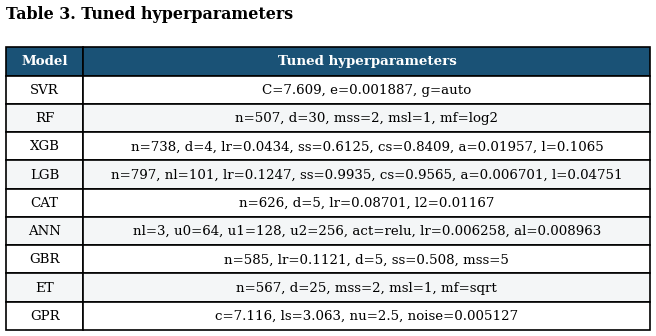

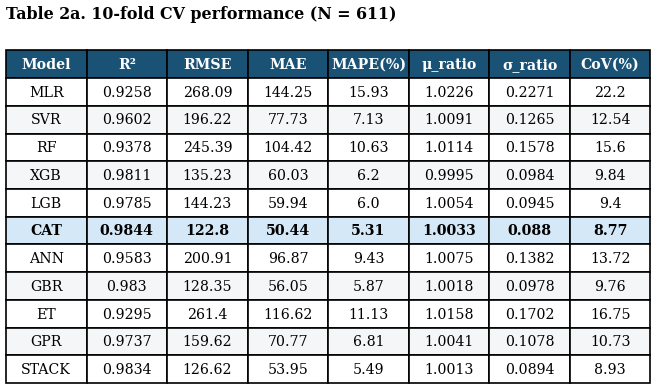

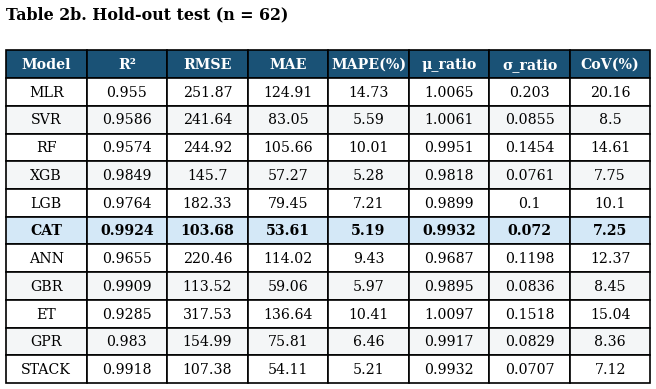

✓ Tables 2a/2b/3 re-rendered cleanly


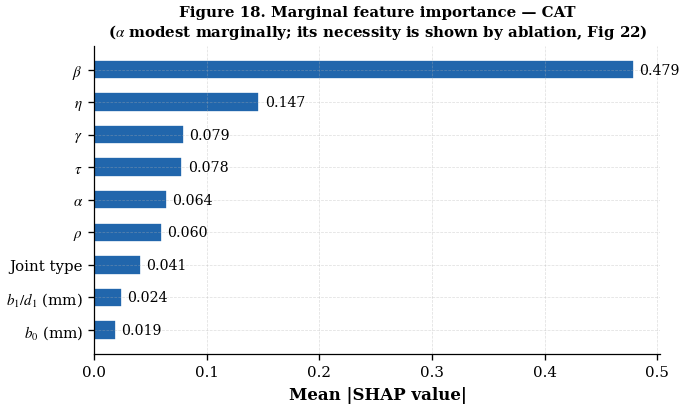

✓ Fig 18 title corrected


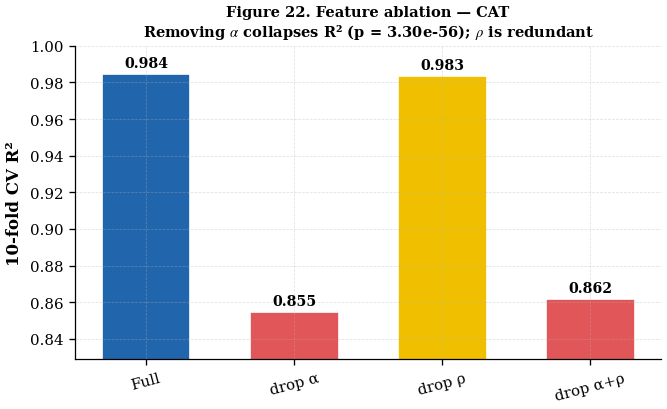

✓ Fig 22 p-value now matches the data


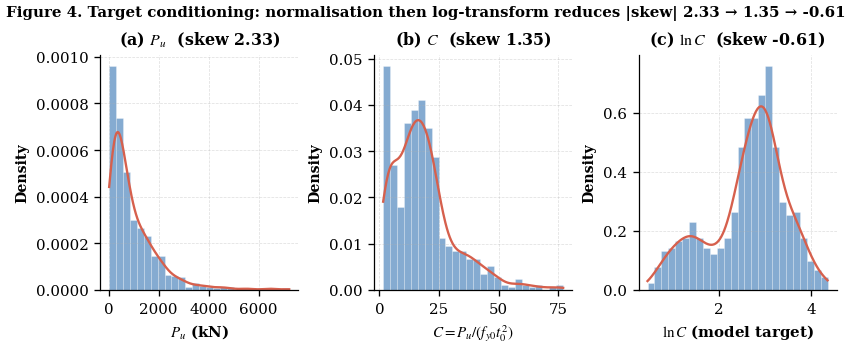

✓ Fig 4 replaced with 3-panel skewness reduction

✓ POLISH COMPLETE — re-saved: Table2a, Table2b, Table3, Fig18, Fig22, Fig04, + new Hyperparameter_Table.csv


In [ ]:
# ================================================================================
#  FINAL POLISH — run as a new cell AFTER the main pipeline (variables in memory)
#  Fixes: Table 3 overflow · Table 2 title overlap · Fig 18 title · Fig 22 p-value
#  Adds : Hyperparameter_Table.csv · Fig 4 skewness-reduction (Pu → C → ln C)
# ================================================================================
import textwrap, json
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew

# ── 1. HYPERPARAMETER TABLE AS CSV (readable names + search ranges + tuned values)
RANGES = {  # (readable name, search range, key in best_params)
 'MLR':[('None (OLS)','—',None)],
 'SVR':[('C (regularisation)','0.1–500 (log)','C'),('ε (tube width)','0.001–0.5 (log)','e'),
        ('γ (kernel)','scale / auto','g')],
 'RF' :[('n_estimators','100–600','n'),('max_depth','5–30','d'),
        ('min_samples_split','2–10','mss'),('min_samples_leaf','1–6','msl'),
        ('max_features','sqrt / log2','mf')],
 'XGB':[('n_estimators','100–800','n'),('max_depth','3–9','d'),('learning_rate','0.01–0.30 (log)','lr'),
        ('subsample','0.5–1.0','ss'),('colsample_bytree','0.5–1.0','cs'),
        ('reg_alpha (L1)','1e-4–1 (log)','a'),('reg_lambda (L2)','1e-4–1 (log)','l')],
 'LGB':[('n_estimators','100–800','n'),('num_leaves','15–127','nl'),('learning_rate','0.01–0.30 (log)','lr'),
        ('subsample','0.5–1.0','ss'),('colsample_bytree','0.5–1.0','cs'),
        ('reg_alpha','1e-4–1 (log)','a'),('reg_lambda','1e-4–1 (log)','l')],
 'CAT':[('iterations','100–800','n'),('depth','4–10','d'),('learning_rate','0.01–0.30 (log)','lr'),
        ('l2_leaf_reg','1e-3–10 (log)','l2')],
 'ANN':[('hidden layers','2–4','nl'),('activation','relu / tanh','act'),
        ('learning_rate_init','5e-4–5e-2 (log)','lr'),('alpha (L2)','1e-5–1e-2 (log)','al')],
 'GBR':[('n_estimators','100–600','n'),('learning_rate','0.01–0.30 (log)','lr'),
        ('max_depth','2–8','d'),('subsample','0.5–1.0','ss'),('min_samples_split','2–10','mss')],
 'ET' :[('n_estimators','100–600','n'),('max_depth','5–30','d'),
        ('min_samples_split','2–10','mss'),('min_samples_leaf','1–6','msl'),
        ('max_features','sqrt / log2','mf')],
 'GPR':[('constant C','0.1–10','c'),('length_scale','0.01–10 (log)','ls'),
        ('Matérn ν','0.5 / 1.5 / 2.5','nu'),('noise level','1e-5–1 (log)','noise')],
}
def fmt(v): return f'{v:.4g}' if isinstance(v,float) else str(v)
hp_rows=[]
for m, plist in RANGES.items():
    if m=='ANN' and best_params.get('ANN'):                      # show ANN layer sizes explicitly
        layers='('+','.join(str(best_params['ANN'][f'u{i}']) for i in range(best_params['ANN']['nl']))+')'
    for name, rng, key in plist:
        if key is None:
            tuned='—'
        elif m=='ANN' and key=='nl':
            tuned=f"{best_params['ANN']['nl']} layers {layers}"
        else:
            tuned=fmt(best_params.get(m,{}).get(key,'—'))
        hp_rows.append([m, name, rng, tuned])
df_hp=pd.DataFrame(hp_rows, columns=['Model','Hyperparameter','Search range','Tuned value'])
df_hp.to_csv(OUT+'Hyperparameter_Table.csv', index=False)
print("✓ Hyperparameter_Table.csv saved (readable names + ranges + tuned values)")

# ── 2. CLEAN TABLE RENDERER (bbox leaves room for title; optional text wrapping) ─
def render_table(dft, title, fname, fig_h, best_row=None, fs=8, colw=None, wrap=None):
    fig, ax = plt.subplots(figsize=(W2, fig_h)); ax.axis('off'); cols=list(dft.columns)
    cell=dft.values.tolist()
    if wrap:
        cell=[['\n'.join(textwrap.wrap(str(v),wrap)) if isinstance(v,str) and len(str(v))>wrap else v
               for v in row] for row in cell]
    tbl=ax.table(cellText=cell, colLabels=cols, cellLoc='center', bbox=[0,0,1,0.90])
    tbl.auto_set_font_size(False); tbl.set_fontsize(fs)
    if colw:
        for j,wv in enumerate(colw):
            for i in range(len(dft)+1): tbl[i,j].set_width(wv)
    for j in range(len(cols)):
        tbl[0,j].set_facecolor('#1a5276'); tbl[0,j].set_text_props(color='white',fontweight='bold')
    for i in range(1,len(dft)+1):
        for j in range(len(cols)): tbl[i,j].set_facecolor('#f4f6f7' if i%2==0 else 'white')
    if best_row is not None:
        for j in range(len(cols)):
            tbl[best_row+1,j].set_facecolor('#d4e8f7'); tbl[best_row+1,j].set_text_props(fontweight='bold')
    ax.set_title(title, fontsize=9.5, fontweight='bold', loc='left', y=0.96)
    fig.savefig(OUT+fname, bbox_inches='tight'); plt.show(); plt.close(fig)

# Table 3 — wrapped one-line-per-model hyperparameters (no overflow)
hp_compact=[[m, ', '.join(f'{k}={fmt(v)}' for k,v in best_params[m].items())]
            for m in best_params if best_params[m]]
render_table(pd.DataFrame(hp_compact, columns=['Model','Tuned hyperparameters']),
             'Table 3. Tuned hyperparameters', 'Table3_Hyperparams.png', 3.4,
             fs=8, colw=[0.12,0.88], wrap=72)

# Table 2a / 2b — title no longer overlaps header
render_table(df_cv, f'Table 2a. 10-fold CV performance (N = {len(df)})', 'Table2a_CV.png', 4.0,
             best_row=int(df_cv['R²'].idxmax()), fs=8.5)
render_table(df_te, f'Table 2b. Hold-out test (n = {len(ite)})', 'Table2b_Test.png', 4.0,
             best_row=int(df_te['R²'].idxmax()), fs=8.5)
print("✓ Tables 2a/2b/3 re-rendered cleanly")

# ── 3. FIG 18 — honest SHAP title (α modest marginally; lead with ablation) ─────
order=np.argsort(msv)
fig, ax = plt.subplots(figsize=(W1*1.7, 3.4), layout='constrained')
ax.barh([FEAT_LABELS[i] for i in order], msv[order], color='#2166ac', edgecolor='white', height=0.6)
for i,v in enumerate(msv[order]): ax.text(v+max(msv)*0.01, i, f'{v:.3f}', va='center', fontsize=8.5)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Figure 18. Marginal feature importance — {shap_nm}\n'
             r'($\alpha$ modest marginally; its necessity is shown by ablation, Fig 22)',
             fontsize=9, fontweight='bold')
clean_ax(ax); fig.savefig(OUT+'Fig18_SHAP_Importance.png'); plt.show(); plt.close(fig)
print("✓ Fig 18 title corrected")

# ── 4. FIG 22 — dynamic p-value read from the ablation result ────────────────────
labs=df_abl['Configuration'].tolist(); vals=[float(v) for v in df_abl['R²']]
p_alpha=df_abl.iloc[1]['Wilcoxon p']      # 'drop alpha' row
short=['Full','drop α','drop ρ','drop α+ρ']
cols=['#2166ac','#e15759','#f0c000','#e15759']
fig, ax = plt.subplots(figsize=(W2*0.8, 3.4), layout='constrained')
ax.bar(short, vals, color=cols, edgecolor='white', width=0.6)
for i,v in enumerate(vals): ax.text(i, v+0.004, f'{v:.3f}', ha='center', fontsize=8.5, fontweight='bold')
ax.set_ylabel('10-fold CV R²'); ax.set_ylim(min(vals)*0.97, 1.0); ax.tick_params(axis='x', rotation=15)
ax.set_title(f'Figure 22. Feature ablation — {best_cv}\n'
             rf'Removing $\alpha$ collapses R² (p = {p_alpha}); $\rho$ is redundant',
             fontsize=8.8, fontweight='bold')
clean_ax(ax); fig.savefig(OUT+'Fig22_Ablation.png'); plt.show(); plt.close(fig)
print("✓ Fig 22 p-value now matches the data")

# ── 5. FIG 4 — skewness reduction:  Pu  →  C  →  ln C  ──────────────────────────
lnC = y    # main pipeline already defines y = ln(C)
panels=[(Pu,'$P_u$ (kN)',f'(a) $P_u$  (skew {skew(Pu):.2f})'),
        (C, '$C = P_u/(f_{y0}t_0^2)$', f'(b) $C$  (skew {skew(C):.2f})'),
        (lnC,'$\\ln C$ (model target)', f'(c) $\\ln C$  (skew {skew(lnC):.2f})')]
fig, ax = plt.subplots(1, 3, figsize=(W2, 2.9), layout='constrained')
for a,(data,xl,tl) in zip(ax, panels):
    a.hist(data, bins=26, color='#2166ac', alpha=0.55, density=True, edgecolor='white', linewidth=0.3)
    kx=np.linspace(data.min(),data.max(),250); a.plot(kx, stats.gaussian_kde(data)(kx), '#d6604d', lw=1.4)
    a.set_xlabel(xl, fontsize=9); a.set_ylabel('Density', fontsize=8.5); a.set_title(tl, fontsize=9.5); clean_ax(a)
fig.suptitle('Figure 4. Target conditioning: normalisation then log-transform reduces |skew| '
             f'{skew(Pu):.2f} → {skew(C):.2f} → {skew(lnC):.2f}',
             fontsize=9, fontweight='bold')
fig.savefig(OUT+'Fig04_Target_Distribution.png'); plt.show(); plt.close(fig)
print("✓ Fig 4 replaced with 3-panel skewness reduction")

print("\n✓ POLISH COMPLETE — re-saved: Table2a, Table2b, Table3, Fig18, Fig22, Fig04, "
      "+ new Hyperparameter_Table.csv")

In [ ]:
# ================================================================
#  Export your trained CatBoost model to ONNX  +  verify it matches
#  Auto-detects your model + feature matrix, so names don't matter.
#  Run this AFTER your CatBoost model is trained (same notebook).
# ================================================================
FEATURES = ['beta', 'tau', 'gamma', 'eta', 'Joint_Type',
            'Chord_B', 'Web_D', 'alpha', 'rho']

!pip -q install onnxruntime          # (ONNX export is built into catboost)

import numpy as np, pandas as pd
import onnxruntime as ort
from catboost import CatBoostRegressor

# --- find your trained CatBoost model automatically -------------
_models = {n: v for n, v in globals().items()
           if isinstance(v, CatBoostRegressor) and v.is_fitted()}
assert _models, ("No *fitted* CatBoostRegressor found. Re-run your training "
                 "cell first (Runtime > Run all), then run this cell.")
model = list(_models.values())[-1]           # the most recently defined one
print("using model variable :", list(_models.keys())[-1])

# --- build the feature matrix X in the correct column order -----
#  tries to find a DataFrame that has all 9 FEATURES columns
X = None
for n, v in globals().items():
    if isinstance(v, pd.DataFrame) and all(c in v.columns for c in FEATURES):
        X = v[FEATURES].to_numpy(); print("using features from  :", n); break
if X is None:                                # fall back to a matrix named X / X_train
    for n in ['X', 'X_train', 'X_full', 'X_all', 'Xtr']:
        if n in globals():
            X = np.asarray(globals()[n]); print("using features from  :", n); break
assert X is not None, ("Couldn't find your feature matrix. Set it manually, e.g.:  "
                       "X = df[FEATURES].to_numpy()")

# 1) Export CatBoost -> ONNX -------------------------------------
model.save_model("tjoint_catboost.onnx", format="onnx")
print("saved  tjoint_catboost.onnx")

# 2) Verify the ONNX reproduces CatBoost's own numbers ----------
Xf   = np.ascontiguousarray(np.asarray(X, dtype=np.float32))
sess = ort.InferenceSession("tjoint_catboost.onnx")
in_name, out_name = sess.get_inputs()[0].name, sess.get_outputs()[0].name
onnx_pred = np.asarray(sess.run([out_name], {in_name: Xf})[0]).ravel()
cat_pred  = model.predict(Xf)
max_diff  = float(np.max(np.abs(onnx_pred - cat_pred)))
print(f"input/output names : {in_name} / {out_name}")
print(f"max |ONNX - CatBoost| : {max_diff:.2e}")
print("MATCH - safe to deploy" if max_diff < 1e-4
      else "MISMATCH - check feature order / Joint_Type is numeric 0-1")

# 3) Download the file, then drop it next to your HTML ----------
from google.colab import files
files.download("tjoint_catboost.onnx")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 63.5 MB/s eta 0:00:00
using model variable : abl_est
using features from  : df
saved  tjoint_catboost.onnx
input/output names : features / predictions
max |ONNX - CatBoost| : 1.60e-06
MATCH - safe to deploy


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ================================================================
#  CELL 31 — Export the EXACT CatBoost champion to ONNX
#  Run this AFTER Cell 9 has completed (fitted dict must exist).
# ================================================================
!pip -q install onnxruntime

import numpy as np
import onnxruntime as ort
from catboost import CatBoostRegressor

# --- Step 1: pull the bare CatBoost estimator out of its Pipeline ---
cat_pipeline = fitted['CAT']                        # Pipeline([scaler, CatBoostRegressor])
cat_estimator = cat_pipeline.named_steps['model']   # the bare CatBoostRegressor
scaler        = cat_pipeline.named_steps['scaler']  # the StandardScaler

print(f"Model type  : {type(cat_estimator)}")
print(f"Is fitted   : {cat_estimator.is_fitted()}")
print(f"Iterations  : {cat_estimator.tree_count_}")

# --- Step 2: build X with the scaler applied (exactly as the pipeline does) ---
# Feature order must match training exactly
FEATURES = ['beta', 'tau', 'gamma', 'eta', 'Joint_Type',
            'Chord_B', 'Web_D', 'alpha', 'rho']
X_raw = df[FEATURES].to_numpy()          # raw features, same 611 rows
X_scaled = scaler.transform(X_raw)       # apply the fitted scaler

# --- Step 3: export the bare CatBoost estimator to ONNX ---
cat_estimator.save_model("tjoint_catboost.onnx", format="onnx")
print("saved  tjoint_catboost.onnx")

# --- Step 4: verify ONNX matches CatBoost on scaled features ---
Xf = np.ascontiguousarray(X_scaled.astype(np.float32))
sess = ort.InferenceSession("tjoint_catboost.onnx")
in_name  = sess.get_inputs()[0].name
out_name = sess.get_outputs()[0].name

onnx_pred = np.asarray(sess.run([out_name], {in_name: Xf})[0]).ravel()
cat_pred  = cat_estimator.predict(Xf)
max_diff  = float(np.max(np.abs(onnx_pred - cat_pred)))

print(f"input name  : {in_name}")
print(f"output name : {out_name}")
print(f"max |ONNX - CatBoost| over 611 specimens : {max_diff:.2e}")
print("✓ MATCH — safe to deploy" if max_diff < 1e-4
      else "✗ MISMATCH — check feature order or dtype")

# --- Step 5: also print the scaler params so we can hard-code them in the HTML ---
print(f"\nScaler mean_  : {list(np.round(scaler.mean_, 6))}")
print(f"Scaler scale_ : {list(np.round(scaler.scale_, 6))}")

# --- Step 6: download ---
from google.colab import files
files.download("tjoint_catboost.onnx")

Model type  : <class 'catboost.core.CatBoostRegressor'>
Is fitted   : True
Iterations  : 626
saved  tjoint_catboost.onnx
input name  : features
output name : predictions
max |ONNX - CatBoost| over 611 specimens : 2.60e-06
✓ MATCH — safe to deploy

Scaler mean_  : [np.float64(0.741138), np.float64(0.909562), np.float64(16.406157), np.float64(0.563972), np.float64(0.66), np.float64(227.440909), np.float64(165.998909), np.float64(2.982272), np.float64(1.177872)]
Scaler scale_ : [np.float64(0.218586), np.float64(0.165605), np.float64(6.395541), np.float64(0.456448), np.float64(0.473709), np.float64(118.606399), np.float64(100.300369), np.float64(1.415629), np.float64(0.718234)]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Final spot-check — should print ~738 kN
spec = np.array([[0.750, 1.000, 15.000, 0.900, 1.0, 180, 135, 1.7833, 0.5556]])
lnC  = fitted['CAT'].predict(spec)[0]
Pu   = np.exp(lnC) * 960 * 6**2 / 1000
print(f"Python CatBoost prediction: {Pu:.1f} kN")

Python CatBoost prediction: 738.5 kN
